In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [48]:
import numpy as np
import pandas as pd
from pathlib import Path

PROJECT = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")
REGD    = PROJECT / "data" / "regression"
STERD   = REGD / "sters"

BREAK_DATA = Path("/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression/break_data_TINV_clim.dta")

# choose ONE product first
PRODUCT = "GMFD"

# choose ONE model stem you actually exported
MODEL_STEM = "FD_FGLS_inter_TINV_clim_quadinter"   # change if your files differ

COEF_PATH = STERD / f"{MODEL_STEM}_{PRODUCT}_coeff.csv"
VCOV_PATH = STERD / f"{MODEL_STEM}_{PRODUCT}_vcov_long.csv"  # ignore for now

print("coef:", COEF_PATH)
print("exists?", COEF_PATH.exists())
print("break_data exists?", BREAK_DATA.exists())


coef: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_inter_TINV_clim_quadinter_GMFD_coeff.csv
exists? True
break_data exists? True


In [49]:
bd = pd.read_stata(BREAK_DATA)
print("break_data rows:", len(bd))
print("cols sample:", bd.columns[:15].tolist())

# sanity: tpid and tgpid should be 1..3
print("tpid unique:", sorted(bd["tpid"].dropna().unique().tolist()))
print("tgpid unique:", sorted(bd["tgpid"].dropna().unique().tolist()))

# Cell choice (income tercile, climate tercile)
LG = 3  # income tercile (1=poor,3=rich)
TR = 1  # climate tercile (1=hot/high CDD,3=cold/high HDD) in your printout

cell = bd[(bd["tgpid"]==LG) & (bd["tpid"]==TR)].copy()
print("cell rows:", len(cell))

# use the tercile means (should be constant within the cell)
subCDD = float(cell["avgCDD_tpid"].iloc[0])
subHDD = float(cell["avgHDD_tpid"].iloc[0])
subInc = float(cell["avgInc_tgpid"].iloc[0])

print("CELL:", "LG", LG, "TR", TR, "| subInc", subInc, "subCDD", subCDD, "subHDD", subHDD)


break_data rows: 4678
cols sample: ['country', 'year', 'lgdppc_MA15', 'hdd20_TINV_GMFD', 'cdd20_TINV_GMFD', 'gpid', 'tpid', 'tgpid', 'largegpid_electricity', 'largegpid_other_energy', 'cyear', 'pyear', 'p80yr', 'avgCDD_tpid', 'avgHDD_tpid']
tpid unique: [1.0, 2.0, 3.0]
tgpid unique: [1.0, 2.0, 3.0]
cell rows: 368
CELL: LG 3 TR 1 | subInc 9.997271537780762 subCDD 2412.935302734375 subHDD 156.36099243164062


In [49]:
bd = pd.read_stata(BREAK_DATA)
print("break_data rows:", len(bd))
print("cols sample:", bd.columns[:15].tolist())

# sanity: tpid and tgpid should be 1..3
print("tpid unique:", sorted(bd["tpid"].dropna().unique().tolist()))
print("tgpid unique:", sorted(bd["tgpid"].dropna().unique().tolist()))

# Cell choice (income tercile, climate tercile)
LG = 3  # income tercile (1=poor,3=rich)
TR = 1  # climate tercile (1=hot/high CDD,3=cold/high HDD) in your printout

cell = bd[(bd["tgpid"]==LG) & (bd["tpid"]==TR)].copy()
print("cell rows:", len(cell))

# use the tercile means (should be constant within the cell)
subCDD = float(cell["avgCDD_tpid"].iloc[0])
subHDD = float(cell["avgHDD_tpid"].iloc[0])
subInc = float(cell["avgInc_tgpid"].iloc[0])

print("CELL:", "LG", LG, "TR", TR, "| subInc", subInc, "subCDD", subCDD, "subHDD", subHDD)


break_data rows: 4678
cols sample: ['country', 'year', 'lgdppc_MA15', 'hdd20_TINV_GMFD', 'cdd20_TINV_GMFD', 'gpid', 'tpid', 'tgpid', 'largegpid_electricity', 'largegpid_other_energy', 'cyear', 'pyear', 'p80yr', 'avgCDD_tpid', 'avgHDD_tpid']
tpid unique: [1.0, 2.0, 3.0]
tgpid unique: [1.0, 2.0, 3.0]
cell rows: 368
CELL: LG 3 TR 1 | subInc 9.997271537780762 subCDD 2412.935302734375 subHDD 156.36099243164062


In [49]:
bd = pd.read_stata(BREAK_DATA)
print("break_data rows:", len(bd))
print("cols sample:", bd.columns[:15].tolist())

# sanity: tpid and tgpid should be 1..3
print("tpid unique:", sorted(bd["tpid"].dropna().unique().tolist()))
print("tgpid unique:", sorted(bd["tgpid"].dropna().unique().tolist()))

# Cell choice (income tercile, climate tercile)
LG = 3  # income tercile (1=poor,3=rich)
TR = 1  # climate tercile (1=hot/high CDD,3=cold/high HDD) in your printout

cell = bd[(bd["tgpid"]==LG) & (bd["tpid"]==TR)].copy()
print("cell rows:", len(cell))

# use the tercile means (should be constant within the cell)
subCDD = float(cell["avgCDD_tpid"].iloc[0])
subHDD = float(cell["avgHDD_tpid"].iloc[0])
subInc = float(cell["avgInc_tgpid"].iloc[0])

print("CELL:", "LG", LG, "TR", TR, "| subInc", subInc, "subCDD", subCDD, "subHDD", subHDD)


break_data rows: 4678
cols sample: ['country', 'year', 'lgdppc_MA15', 'hdd20_TINV_GMFD', 'cdd20_TINV_GMFD', 'gpid', 'tpid', 'tgpid', 'largegpid_electricity', 'largegpid_other_energy', 'cyear', 'pyear', 'p80yr', 'avgCDD_tpid', 'avgHDD_tpid']
tpid unique: [1.0, 2.0, 3.0]
tgpid unique: [1.0, 2.0, 3.0]
cell rows: 368
CELL: LG 3 TR 1 | subInc 9.997271537780762 subCDD 2412.935302734375 subHDD 156.36099243164062


In [50]:
coef_df = pd.read_csv(COEF_PATH)
print("coef rows:", len(coef_df))
print(coef_df.head())

coef = pd.Series(coef_df["beta"].values, index=coef_df["parm"].astype(str).values)

# print the exact names we will use
want = [
    "c.indp1#c.indf1#c.FD_temp1",
    "c.indp1#c.indf1#c.FD_temp2",
    "c.indp1#c.indf1#c.FD_hdd20_TINVtemp1",
    "c.indp1#c.indf1#c.FD_hdd20_TINVtemp2",
    "c.indp1#c.indf1#c.FD_cdd20_TINVtemp1",
    "c.indp1#c.indf1#c.FD_cdd20_TINVtemp2",
]
missing = [w for w in want if w not in coef.index]
print("missing from coef:", missing)

# show all dc1 params so we pick the right one next
dc1 = [p for p in coef.index if "FD_dc1_lgdppc_MA15" in p and "temp" in p]
print("dc1 params:", dc1)


coef rows: 57
                           parm      beta
0    c.indp1#c.indf1#c.FD_temp1 -0.014005
1    c.indp1#c.indf1#c.FD_temp2  0.000511
2    c.indp2#c.indf1#c.FD_temp1  0.039666
3    c.indp2#c.indf1#c.FD_temp2 -0.000813
4  c.indp1#c.indf1#c.FD_precip1 -0.000002
missing from coef: []
dc1 params: ['c.indp1#c.indf1#c.FD_dc1_lgdppc_MA15I1temp1', 'c.indp1#c.indf1#c.FD_dc1_lgdppc_MA15I1temp2', 'c.indp1#c.indf1#c.FD_dc1_lgdppc_MA15I2temp1', 'c.indp1#c.indf1#c.FD_dc1_lgdppc_MA15I2temp2', 'c.indp2#c.indf1#c.FD_dc1_lgdppc_MA15I1temp1', 'c.indp2#c.indf1#c.FD_dc1_lgdppc_MA15I1temp2', 'c.indp2#c.indf1#c.FD_dc1_lgdppc_MA15I2temp1', 'c.indp2#c.indf1#c.FD_dc1_lgdppc_MA15I2temp2', 'c.indp1#c.indf1#c.FD_dc1_lgdppc_MA15yearI1temp1', 'co.indp1#co.indf1#co.FD_dc1_lgdppc_MA15yearI1temp2', 'c.indp1#c.indf1#c.FD_dc1_lgdppc_MA15yearI2temp1', 'co.indp1#co.indf1#co.FD_dc1_lgdppc_MA15yearI2temp2', 'c.indp2#c.indf1#c.FD_dc1_lgdppc_MA15yearI1temp1', 'co.indp2#co.indf1#co.FD_dc1_lgdppc_MA15yearI1temp2', 'c.indp2

In [58]:
FUEL = "electricity"  # or "other_energy"

FD_PANEL = REGD / f"{PRODUCT}_TINV_clim_regsort.dta"
print("FD panel:", FD_PANEL, "exists?", FD_PANEL.exists())

dfp = pd.read_stata(FD_PANEL)
print("panel rows:", len(dfp))
print("panel cols contain:", [c for c in ["product","largegpid","largegpid_electricity","lgdppc_MA15"] if c in dfp.columns])

# define largegpid consistent with your panel structure
# some panels use largegpid, others have largegpid_electricity/other_energy
if "largegpid" in dfp.columns:
    lgflag = dfp["largegpid"]
else:
    lgflag = dfp[f"largegpid_{FUEL}"]

submax = dfp[(dfp["product"]==FUEL) & (lgflag==1)]["lgdppc_MA15"].max()
print("dc1 anchor (max lgdppc_MA15 among largegpid==1 & fuel):", submax)

dc1_raw = subInc - submax
dc1_val = min(dc1_raw, 0.0)

if dc1_val < 0:
    IG = 1   # below knot
else:
    IG = 2   # above knot (dc1 terms drop out anyway)

print("dc1_val =", dc1_val, "(should usually be <= 0)")


FD panel: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/GMFD_TINV_clim_regsort.dta exists? True
panel rows: 8301
panel cols contain: ['product', 'largegpid', 'lgdppc_MA15']
dc1 anchor (max lgdppc_MA15 among largegpid==1 & fuel): 9.087010110053141
dc1_val = 0.0 (should usually be <= 0)


In [59]:
import numpy as np
import pandas as pd

# --------------------------
# 0) Inputs you already have
# --------------------------
# coef: pandas Series indexed by parm strings
# cell covariates (from your printed tables):
# subCDD, subHDD, subInc = ...
# ibar / anchor (submax) already computed from FD panel:
# submax = 9.087010110053141

# --------------------------
# 1) Helpers
# --------------------------
def get_beta(coef, name, default=0.0):
    """Safe coefficient getter."""
    return float(coef[name]) if name in coef.index else float(default)

def dc1_value(subInc, submax):
    """Remember: negative spline, clipped at 0 above the knot."""
    return min(subInc - submax, 0.0)

def income_group_from_dc1(dc1_val):
    """I1 below knot (dc1<0), I2 above knot (dc1==0)."""
    return 1 if dc1_val < 0 else 2

def temp_poly_terms(T):
    """Return [T, T^2] for your current spec (temp1,temp2)."""
    return T, T**2

# --------------------------
# 2) Choose ONE cell (same as your debug cell)
# --------------------------
# Example: income tercile lg=3, climate tercile tr=1
subInc = 9.997271537780762
subCDD = 2412.935302734375
subHDD = 156.36099243164062

submax = 9.087010110053141  # your printed anchor
dc1_val = dc1_value(subInc, submax)
IG = income_group_from_dc1(dc1_val)

print("CELL:")
print("  subInc =", subInc)
print("  subCDD =", subCDD)
print("  subHDD =", subHDD)
print("  submax(anchor) =", submax)
print("  dc1_val =", dc1_val)
print("  IG =", IG)

# --------------------------
# 3) Build y(T) for ONE pg and one fuel flag (your pg/indp logic)
# --------------------------
# You printed PG=1 and indf1; keep that for now.
PG = 1
F = 1  # indf1

# Temperature grid like paper figs
Tgrid = np.linspace(-15, 45, 301)

# Construct the *exact* coefficient names we will use
# (this matches your coef index style)
def nm(indp, indf, var):
    return f"c.indp{indp}#c.indf{indf}#c.{var}"

# In your earlier prints you were using indp1 for PG=1. Keep that.
indp = PG
indf = F

# Core betas (temp)
b_t1 = get_beta(coef, nm(indp, indf, "FD_temp1"))
b_t2 = get_beta(coef, nm(indp, indf, "FD_temp2"))

# TINV betas
b_cdd1 = get_beta(coef, nm(indp, indf, "FD_cdd20_TINVtemp1"))
b_cdd2 = get_beta(coef, nm(indp, indf, "FD_cdd20_TINVtemp2"))
b_hdd1 = get_beta(coef, nm(indp, indf, "FD_hdd20_TINVtemp1"))
b_hdd2 = get_beta(coef, nm(indp, indf, "FD_hdd20_TINVtemp2"))

# Income-spline betas (these should drop out when dc1_val==0)
b_dc1_t1 = get_beta(coef, nm(indp, indf, f"FD_dc1_lgdppc_MA15I{IG}temp1"))
b_dc1_t2 = get_beta(coef, nm(indp, indf, f"FD_dc1_lgdppc_MA15I{IG}temp2"))

print("\nPARAM CHECK:")
print("  b_t1, b_t2 =", b_t1, b_t2)
print("  b_cdd1, b_cdd2 =", b_cdd1, b_cdd2)
print("  b_hdd1, b_hdd2 =", b_hdd1, b_hdd2)
print("  b_dc1_t1, b_dc1_t2 =", b_dc1_t1, b_dc1_t2)

# Compute y(T) and also component contributions for debugging
y = np.zeros_like(Tgrid, dtype=float)

contrib_temp = np.zeros_like(y)
contrib_tinv = np.zeros_like(y)
contrib_dc1  = np.zeros_like(y)

for i, T in enumerate(Tgrid):
    t1, t2 = temp_poly_terms(T)

    # baseline temp part
    temp_part = b_t1 * t1 + b_t2 * t2

    # TINV interactions: multiply by cell-level CDD/HDD scalars
    tinv_part = (b_cdd1 * subCDD * t1 +
                 b_cdd2 * subCDD * t2 +
                 b_hdd1 * subHDD * t1 +
                 b_hdd2 * subHDD * t2)

    # income spline interactions (should be zero if dc1_val==0)
    dc1_part = dc1_val * (b_dc1_t1 * t1 + b_dc1_t2 * t2)

    contrib_temp[i] = temp_part
    contrib_tinv[i] = tinv_part
    contrib_dc1[i]  = dc1_part

    y[i] = temp_part + tinv_part + dc1_part

print("\nOUTPUT SANITY:")
print("  y min/max:", float(y.min()), float(y.max()))
print("  dc1 contrib min/max:", float(contrib_dc1.min()), float(contrib_dc1.max()))
print("  (dc1 should be exactly 0 everywhere if dc1_val==0)")


CELL:
  subInc = 9.997271537780762
  subCDD = 2412.935302734375
  subHDD = 156.36099243164062
  submax(anchor) = 9.087010110053141
  dc1_val = 0.0
  IG = 2

PARAM CHECK:
  b_t1, b_t2 = -0.0140050277776968 0.0005112519014807
  b_cdd1, b_cdd2 = 1.36451057732e-07 -5.72468672855e-10
  b_hdd1, b_hdd2 = 3.83969097574e-08 2.40220520946e-09
  b_dc1_t1, b_dc1_t2 = -4.407281568810211 -0.0019363734192191

OUTPUT SANITY:
  y min/max: -0.09155519950436561 0.4181085810699167
  dc1 contrib min/max: -0.0 -0.0
  (dc1 should be exactly 0 everywhere if dc1_val==0)


coef: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_inter_TINV_clim_quadinter_GMFD_coeff.csv | exists? True
break_data: /user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression/break_data_TINV_clim.dta | exists? True
ibar_main = 9.087010383605957
Income terciles: {1.0: 7.4978461265563965, 2.0: 8.77016830444336, 3.0: 9.997271537780762}
CDD terciles: {1.0: 2412.935302734375, 2.0: 1115.5257568359375, 3.0: 223.8359832763672}
HDD terciles: {1.0: 156.36099243164062, 2.0: 1178.0726318359375, 3.0: 3925.803955078125}


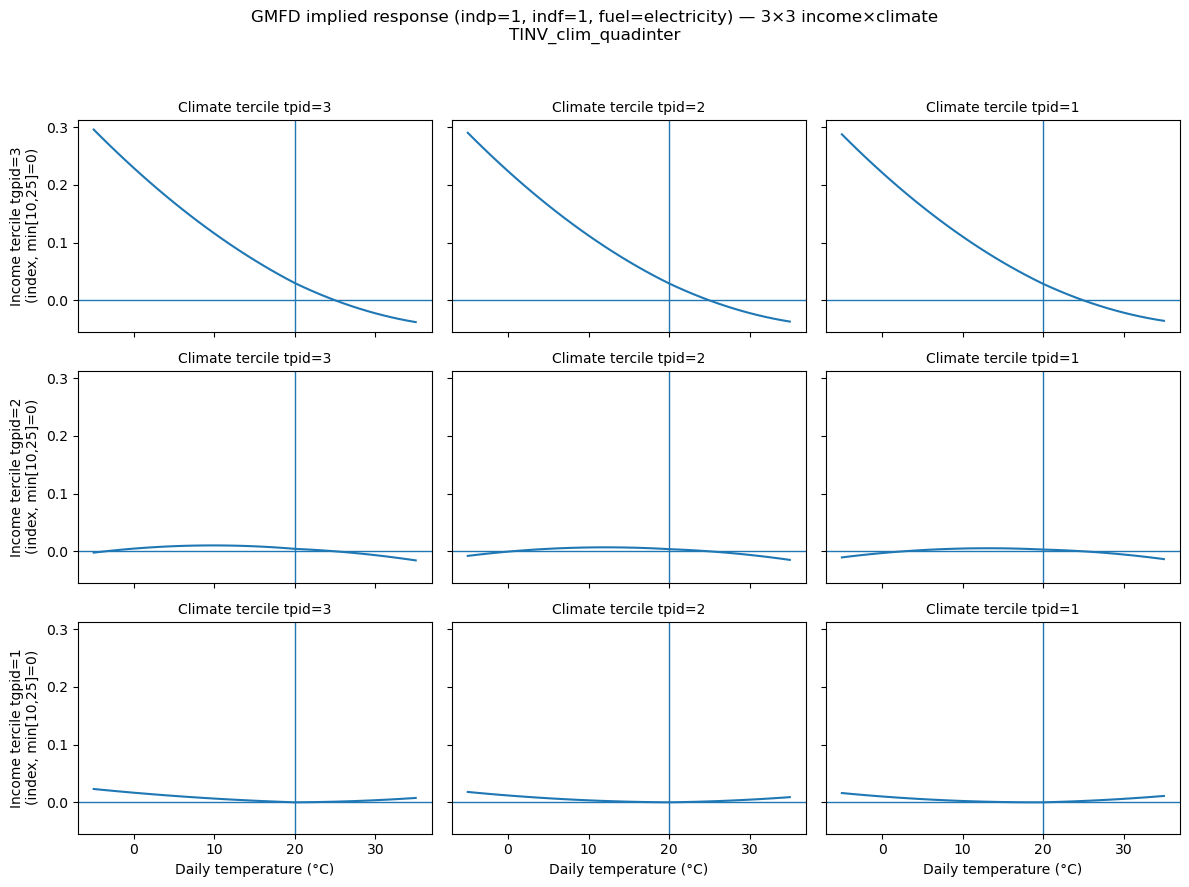


DEBUG (first plotted cell):
{'lg': 3, 'tr': 3, 'subInc': 9.997271537780762, 'subCDD': 223.8359832763672, 'subHDD': 3925.803955078125, 'ibar': 9.087010383605957, 'pg': 1, 'deltacut': 0.9102611541748047, 'ig': 2}

PARAM CHECK (any variant exists?):
  FD_temp1 -> True | ('c.indp1#c.indf1#c.FD_temp1_GMFD', 'c.indp1#c.indf1#c.FD_temp1')
  FD_temp2 -> True | ('c.indp1#c.indf1#c.FD_temp2_GMFD', 'c.indp1#c.indf1#c.FD_temp2')
  FD_cdd20_TINVtemp1 -> True | ('c.indp1#c.indf1#c.FD_cdd20_TINVtemp1_GMFD', 'c.indp1#c.indf1#c.FD_cdd20_TINVtemp1')
  FD_hdd20_TINVtemp1 -> True | ('c.indp1#c.indf1#c.FD_hdd20_TINVtemp1_GMFD', 'c.indp1#c.indf1#c.FD_hdd20_TINVtemp1')
  FD_yeartemp1 -> False | ('c.indp1#c.indf1#c.FD_yeartemp1_GMFD', 'c.indp1#c.indf1#c.FD_yeartemp1')
  FD_year2temp1 -> True | ('c.indp1#c.indf1#c.FD_year2temp1_GMFD', 'c.indp1#c.indf1#c.FD_year2temp1')


In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------
# CONFIG (match Stata)
# -----------------------
PROJECT = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")
DATA    = PROJECT / "data"
REGD    = DATA / "regression"
STERD   = REGD / "sters"

MODEL_MAIN = "TINV_clim_quadinter"     # corresponds to `model_main` in Stata
PRODUCT    = "GMFD"
VAR        = "electricity"             # or "other_energy"
YEAR_PLOT  = 2099                      # Stata local year = 2099

BREAK_DATA = Path("/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression/break_data_TINV_clim.dta")

COEF_PATH = STERD / f"FD_FGLS_inter_{MODEL_MAIN}_{PRODUCT}_coeff.csv"

print("coef:", COEF_PATH, "| exists?", COEF_PATH.exists())
print("break_data:", BREAK_DATA, "| exists?", BREAK_DATA.exists())

# -----------------------
# Step 1: Stata plotting grid exactly: temp1 = -5..35 integer
# -----------------------
T = np.arange(-5, 36, 1).astype(float)
above20 = (T >= 20).astype(float)
below20 = (T <  20).astype(float)

# -----------------------
# Step 2: break_data: ibar and tercile means (same info Stata pulls)
# -----------------------
bd = pd.read_stata(BREAK_DATA)

ibar_col = f"maxInc_largegpid_{VAR}"
lgflag   = f"largegpid_{VAR}"
ibar_main = float(bd.loc[bd[lgflag] == 1, ibar_col].max())
print("ibar_main =", ibar_main)

celltab = bd.drop_duplicates(subset=["tpid", "tgpid"]).sort_values(["tpid", "tgpid"]).reset_index(drop=True)
inc_by_tgpid = celltab.groupby("tgpid")["avgInc_tgpid"].first().to_dict()
cdd_by_tpid  = celltab.groupby("tpid")["avgCDD_tpid"].first().to_dict()
hdd_by_tpid  = celltab.groupby("tpid")["avgHDD_tpid"].first().to_dict()

print("Income terciles:", inc_by_tgpid)
print("CDD terciles:", cdd_by_tpid)
print("HDD terciles:", hdd_by_tpid)

# -----------------------
# Step 3: load coefficients
# -----------------------
coef_df = pd.read_csv(COEF_PATH)
coef = pd.Series(coef_df["beta"].values, index=coef_df["parm"].astype(str).values)

# -----------------------
# Name resolution helpers (THIS is the key fix)
# -----------------------
def coef_get(*candidates, default=0.0):
    """
    Return the first matching coefficient among candidate names.
    """
    for name in candidates:
        if name in coef.index:
            return float(coef[name])
    return float(default)

def nm(pg, indf, term):
    """
    Build candidate parm strings. We try:
      1) term with _GMFD suffix (Stata style)
      2) term without suffix (your CSV style)
    """
    a = f"c.indp{pg}#c.indf{indf}#c.{term}_{PRODUCT}"
    b = f"c.indp{pg}#c.indf{indf}#c.{term}"
    return a, b

# -----------------------
# Step 4: yhat(T) EXACTLY like Stata local `line`
# including quadinter year + year^2 terms
# -----------------------
def yhat_for_cell(pg, subCDD, subHDD, subInc, ibar):
    deltacut = float(subInc - ibar)
    ig = 2 if subInc > ibar else 1   # Stata logic

    y = np.zeros_like(T, dtype=float)

    for k in [1, 2]:
        Tk = T**k
        base = (Tk - 20.0**k)

        # temp term
        b_temp = coef_get(*nm(pg, 1, f"FD_temp{k}"))

        # TINV terms (gated)
        b_cdd  = coef_get(*nm(pg, 1, f"FD_cdd20_TINVtemp{k}"))
        b_hdd  = coef_get(*nm(pg, 1, f"FD_hdd20_TINVtemp{k}"))

        # dc1 term (note: Stata has NO _GMFD suffix on this)
        b_dc1  = coef_get(
            f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15I{ig}temp{k}",
            default=0.0
        )

        # year interactions (lininter/quadinter block in your Stata)
        b_yt   = coef_get(*nm(pg, 1, f"FD_yeartemp{k}"))
        b_dc1y = coef_get(
            f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15yearI{ig}temp{k}",
            default=0.0
        )

        # quadinter extra: year^2 interactions
        b_y2t   = coef_get(*nm(pg, 1, f"FD_year2temp{k}"))
        b_dc1y2 = coef_get(
            f"c.indp{pg}#c.indf1#c.FD_dc1_lgdppc_MA15year2I{ig}temp{k}",
            default=0.0
        )

        # Assemble exactly like Stata:
        y += b_temp * base
        y += above20 * b_cdd * subCDD * base
        y += below20 * b_hdd * subHDD * (20.0**k - Tk)
        y += b_dc1 * deltacut * base

        y += b_yt   * base * YEAR_PLOT
        y += b_dc1y * deltacut * YEAR_PLOT * base

        y += b_y2t   * base * YEAR_PLOT * YEAR_PLOT
        y += b_dc1y2 * deltacut * YEAR_PLOT * YEAR_PLOT * base

    meta = {"deltacut": deltacut, "ig": ig}
    return y, meta

def normalize_min_window(y, lo=10, hi=25):
    mask = (T >= lo) & (T <= hi)
    return y - np.min(y[mask])

# -----------------------
# Step 5: 3×3 plot (match your Stata loop direction)
# Stata loops lg=3..1 and tr=3..1
# -----------------------
pg = 1 if VAR == "electricity" else 2

fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)
fig.suptitle(f"{PRODUCT} implied response (indp={pg}, indf=1, fuel={VAR}) — 3×3 income×climate\n{MODEL_MAIN}", y=0.98)

first_meta = None

for r, lg in enumerate([3, 2, 1]):
    for c, tr in enumerate([3, 2, 1]):
        subInc = float(inc_by_tgpid[float(lg)])
        subCDD = float(cdd_by_tpid[float(tr)])
        subHDD = float(hdd_by_tpid[float(tr)])

        y_raw, meta = yhat_for_cell(pg, subCDD, subHDD, subInc, ibar_main)
        y = normalize_min_window(y_raw, 10, 25)

        ax = axes[r, c]
        ax.plot(T, y)
        ax.axhline(0, linewidth=1)
        ax.axvline(20, linewidth=1)
        ax.set_title(f"Climate tercile tpid={tr}", fontsize=10)

        if c == 0:
            ax.set_ylabel(f"Income tercile tgpid={lg}\n(index, min[10,25]=0)", fontsize=10)
        if r == 2:
            ax.set_xlabel("Daily temperature (°C)")

        if first_meta is None:
            first_meta = {"lg": lg, "tr": tr, "subInc": subInc, "subCDD": subCDD, "subHDD": subHDD,
                          "ibar": ibar_main, "pg": pg, **meta}

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\nDEBUG (first plotted cell):")
print(first_meta)

# -----------------------
# QUICK PARAM EXISTENCE CHECK (now should be True)
# -----------------------
check = [
    *nm(pg, 1, "FD_temp1"),
    *nm(pg, 1, "FD_temp2"),
    *nm(pg, 1, "FD_cdd20_TINVtemp1"),
    *nm(pg, 1, "FD_hdd20_TINVtemp1"),
    *nm(pg, 1, "FD_yeartemp1"),
    *nm(pg, 1, "FD_year2temp1"),
]
print("\nPARAM CHECK (any variant exists?):")
for base in ["FD_temp1","FD_temp2","FD_cdd20_TINVtemp1","FD_hdd20_TINVtemp1","FD_yeartemp1","FD_year2temp1"]:
    cand = nm(pg, 1, base)
    print(" ", base, "->", any(x in coef.index for x in cand), "|", cand)


In [71]:
y11, m11 = y_cell(3, 1)
y13, m13 = y_cell(3, 3)
print("meta rich-hot:", m11)
print("meta rich-cold:", m13)


meta rich-hot: {'lg': 3, 'tr': 1, 'subInc': 9.997271537780762, 'subCDD': 2412.935302734375, 'subHDD': 156.36099243164062, 'indp': 1, 'ibar': 12.413788795471191, 'dc1': 0.0, 'IG': 2}
meta rich-cold: {'lg': 3, 'tr': 3, 'subInc': 9.997271537780762, 'subCDD': 223.83599853515625, 'subHDD': 3925.803955078125, 'indp': 1, 'ibar': 12.413788795471191, 'dc1': 0.0, 'IG': 2}


In [72]:
for lg in [1,2,3]:
    for tr in [1,2,3]:
        _, meta = y_cell(lg, tr)
        print(lg, tr, "indp", meta["indp"], "dc1", round(meta["dc1"],3), "IG", meta["IG"])


1 1 indp 1 dc1 -1.589 IG 1
1 2 indp 1 dc1 -1.589 IG 1
1 3 indp 1 dc1 -1.589 IG 1
2 1 indp 1 dc1 -0.317 IG 1
2 2 indp 1 dc1 -0.317 IG 1
2 3 indp 1 dc1 -0.317 IG 1
3 1 indp 1 dc1 0.0 IG 2
3 2 indp 1 dc1 0.0 IG 2
3 3 indp 1 dc1 0.0 IG 2


coef: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_inter_TINV_clim_quadinter_GMFD_coeff.csv | exists? True
break_data: /user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression/break_data_TINV_clim.dta | exists? True
ibar_main = 9.087010383605957
Income terciles: {1: 7.4978461265563965, 2: 8.77016830444336, 3: 9.997271537780762}
CDD terciles: {1: 2412.935302734375, 2: 1115.5257568359375, 3: 223.8359832763672}
HDD terciles: {1: 156.36099243164062, 2: 1178.0726318359375, 3: 3925.803955078125}


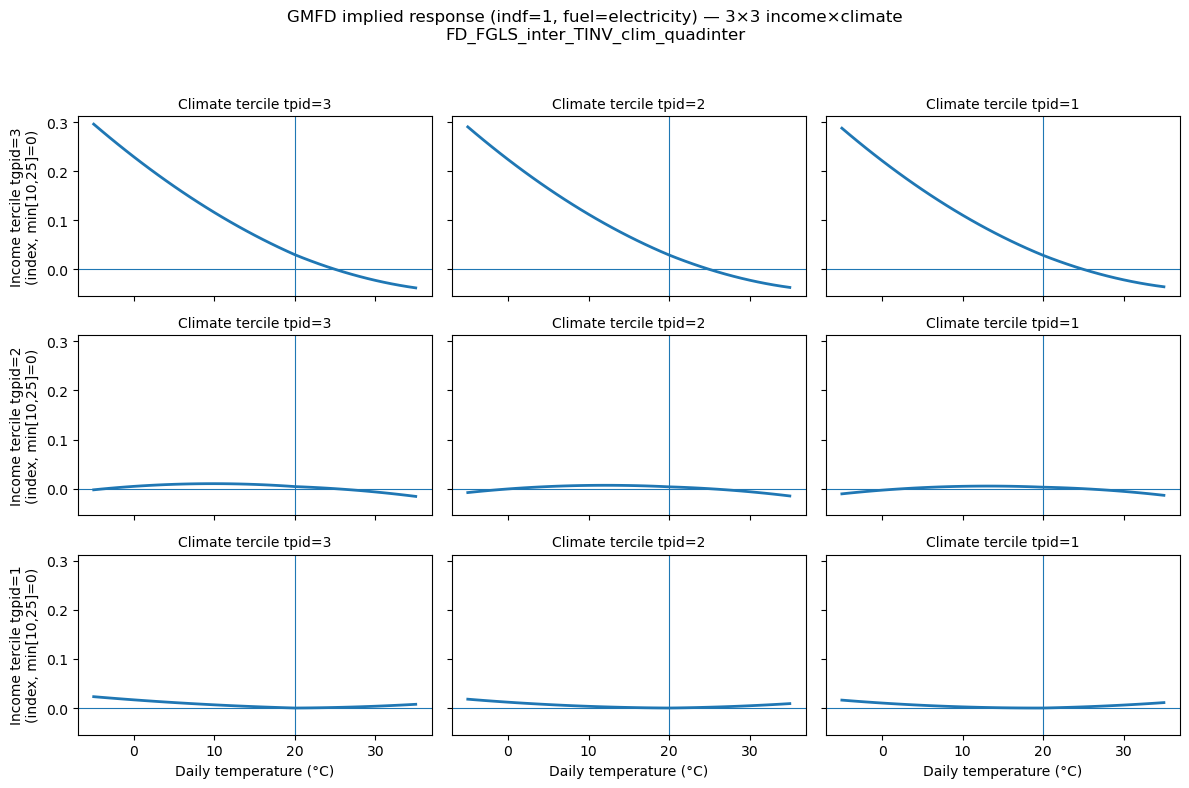


DEBUG (first plotted cell):
{'lg': 3, 'tr': 3, 'subInc': 9.997271537780762, 'subCDD': 223.8359832763672, 'subHDD': 3925.803955078125, 'ibar': 9.087010383605957, 'pg': 1, 'deltacut': 0.9102611541748047, 'ig': 2}

PARAM CHECK (spot):
  yeartemp1 found? True | ['co.indp1#co.indf1#co.FD_yeartemp1']
  yeartemp2 found? True | ['co.indp1#co.indf1#co.FD_yeartemp2']


In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# Paths / settings
# -----------------------------
PROJECT = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")
REGD    = PROJECT / "data" / "regression"
STERD   = REGD / "sters"

BREAK_DATA = Path("/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression/break_data_TINV_clim.dta")

PRODUCT    = "GMFD"
MODEL_STEM = "FD_FGLS_inter_TINV_clim_quadinter"   # your stem
COEF_PATH  = STERD / f"{MODEL_STEM}_{PRODUCT}_coeff.csv"

FUEL       = "electricity"   # "electricity" or "other_energy"
IND_F      = 1               # indf1 in your do-file
YEAR_PLOT  = 2099            # matches do-file local year

TMIN, TMAX = -5, 35
T = np.arange(TMIN, TMAX + 1, 1.0)  # matches Stata: _n-6 gives -5..35
ABOVE20 = (T >= 20).astype(float)
BELOW20 = (T < 20).astype(float)

# -----------------------------
# Helpers
# -----------------------------
def read_coeff(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    return pd.Series(df["beta"].values, index=df["parm"].astype(str).values)

def get_beta(coef: pd.Series, candidates: list[str], default=0.0) -> float:
    for nm in candidates:
        if nm in coef.index:
            return float(coef[nm])
    return float(default)

def candidates(indp: int, indf: int, var: str, product: str) -> list[str]:
    """
    Try all name variants you have seen:
      - c. ... #c. ...
      - co.... #co....
      - with and without _GMFD suffix
    """
    return [
        f"c.indp{indp}#c.indf{indf}#c.{var}_{product}",
        f"c.indp{indp}#c.indf{indf}#c.{var}",
        f"co.indp{indp}#co.indf{indf}#co.{var}_{product}",
        f"co.indp{indp}#co.indf{indf}#co.{var}",
    ]

def ibar_from_breakdata(bd: pd.DataFrame, fuel: str) -> float:
    # Stata: summ maxInc_largegpid_`var' if largegpid_`var' == 1 ; local ibar = r(max)
    maxcol  = f"maxInc_largegpid_{fuel}"
    flagcol = f"largegpid_{fuel}"
    sub = bd.loc[bd[flagcol] == 1, maxcol]
    return float(sub.max())

def tercile_means_from_breakdata(bd: pd.DataFrame):
    # mimic the Stata indexing:
    # duplicates drop tpid tgpid, force ; sort tpid tgpid
    b = bd.drop_duplicates(subset=["tpid", "tgpid"]).copy()
    b = b.sort_values(["tpid", "tgpid"]).reset_index(drop=True)
    return b

def covariates_for_cell(b_sorted: pd.DataFrame, lg: int, tr: int):
    # Stata:
    # local tr_index = tr * 3
    # local subCDD = avgCDD_tpid[tr_index]
    # local subHDD = avgHDD_tpid[tr_index]
    # local subInc = avgInc_tgpid[lg]
    #
    # Note: Stata indices are 1-based. Python is 0-based.
    tr_index_stata = tr * 3
    tr_row = tr_index_stata - 1
    lg_row = lg - 1

    subCDD = float(b_sorted.loc[tr_row, "avgCDD_tpid"])
    subHDD = float(b_sorted.loc[tr_row, "avgHDD_tpid"])
    subInc = float(b_sorted.loc[lg_row, "avgInc_tgpid"])
    return subCDD, subHDD, subInc

def response_curve_for_cell(coef: pd.Series, fuel: str, lg: int, tr: int,
                            subCDD: float, subHDD: float, subInc: float, ibar: float,
                            indf: int, product: str, year_plot: int):
    # pg selection matches Stata:
    pg = 1 if fuel == "electricity" else 2
    ig = 2 if subInc > ibar else 1
    deltacut = subInc - ibar  # IMPORTANT: NOT clipped in Stata

    # Build y(T) exactly like Stata line:
    # sum_{k=1,2} [
    #   b_tempk * (temp^k - 20^k)
    # + above20 * b_cddk * subCDD * (temp^k - 20^k)
    # + below20 * b_hddk * subHDD * (20^k - temp^k)
    # + b_dc1k * deltacut * (temp^k - 20^k)
    # + b_yeartempk * (temp^k - 20^k)*year
    # + b_dc1yeark * deltacut*year*(temp^k - 20^k)
    # + b_year2tempk * (temp^k - 20^k)*year^2
    # + b_dc1year2k * deltacut*year^2*(temp^k - 20^k)
    # ]
    y = np.zeros_like(T, dtype=float)

    for k in [1, 2]:
        Tk = T**k
        dT = Tk - (20.0**k)          # (temp^k - 20^k)
        dT_below = (20.0**k) - Tk    # (20^k - temp^k)

        b_temp  = get_beta(coef, candidates(pg, indf, f"FD_temp{k}", product))
        b_cdd   = get_beta(coef, candidates(pg, indf, f"FD_cdd20_TINVtemp{k}", product))
        b_hdd   = get_beta(coef, candidates(pg, indf, f"FD_hdd20_TINVtemp{k}", product))
        b_dc1   = get_beta(coef, candidates(pg, indf, f"FD_dc1_lgdppc_MA15I{ig}temp{k}", product))

        # year terms: you showed these are "co." for yeartemp and dc1...year...
        b_yt    = get_beta(coef, candidates(pg, indf, f"FD_yeartemp{k}", product))
        b_dc1y  = get_beta(coef, candidates(pg, indf, f"FD_dc1_lgdppc_MA15yearI{ig}temp{k}", product))

        # year^2 terms: you showed these are "c." for year2temp and dc1...year2...
        b_y2t   = get_beta(coef, candidates(pg, indf, f"FD_year2temp{k}", product))
        b_dc1y2 = get_beta(coef, candidates(pg, indf, f"FD_dc1_lgdppc_MA15year2I{ig}temp{k}", product))

        y += b_temp * dT
        y += ABOVE20 * (b_cdd * subCDD * dT)
        y += BELOW20 * (b_hdd * subHDD * dT_below)
        y += (b_dc1 * deltacut * dT)

        y += (b_yt * dT * year_plot)
        y += (b_dc1y * deltacut * year_plot * dT)

        y += (b_y2t * dT * (year_plot**2))
        y += (b_dc1y2 * deltacut * (year_plot**2) * dT)

    # Stata normalizes by subtracting min over [10,25] (in your plots)
    mask = (T >= 10) & (T <= 25)
    y = y - np.min(y[mask])

    meta = dict(
        lg=lg, tr=tr, subInc=subInc, subCDD=subCDD, subHDD=subHDD,
        ibar=ibar, pg=(1 if fuel=="electricity" else 2),
        deltacut=deltacut, ig=ig
    )
    return y, meta

# -----------------------------
# Main
# -----------------------------
assert COEF_PATH.exists(), f"Missing coef file: {COEF_PATH}"
assert BREAK_DATA.exists(), f"Missing break_data file: {BREAK_DATA}"

coef = read_coeff(COEF_PATH)

bd = pd.read_stata(BREAK_DATA)
b_sorted = tercile_means_from_breakdata(bd)
ibar = ibar_from_breakdata(bd, FUEL)

print("coef:", COEF_PATH, "| exists?", COEF_PATH.exists())
print("break_data:", BREAK_DATA, "| exists?", BREAK_DATA.exists())
print("ibar_main =", ibar)

# Precompute covariates for each tercile (for your printed sanity)
inc_map = {int(k): float(v) for k, v in b_sorted.groupby("tgpid")["avgInc_tgpid"].first().items()}
cdd_map = {int(k): float(v) for k, v in b_sorted.groupby("tpid")["avgCDD_tpid"].first().items()}
hdd_map = {int(k): float(v) for k, v in b_sorted.groupby("tpid")["avgHDD_tpid"].first().items()}
print("Income terciles:", inc_map)
print("CDD terciles:", cdd_map)
print("HDD terciles:", hdd_map)

# 3x3 plot (rows: lg=3..1, cols: tr=3..1)
fig, axes = plt.subplots(3, 3, figsize=(12, 8), sharex=True, sharey=True)
fig.suptitle(
    f"{PRODUCT} implied response (indf={IND_F}, fuel={FUEL}) — 3×3 income×climate\n{MODEL_STEM}",
    y=0.98
)

first_meta = None

for r, lg in enumerate([3, 2, 1]):          # rows: rich -> poor
    for c, tr in enumerate([3, 2, 1]):      # cols: cold -> hot (matches your Stata loop tr=3(-1)1)
        ax = axes[r, c]
        subCDD, subHDD, subInc = covariates_for_cell(b_sorted, lg, tr)
        y, meta = response_curve_for_cell(
            coef=coef, fuel=FUEL, lg=lg, tr=tr,
            subCDD=subCDD, subHDD=subHDD, subInc=subInc, ibar=ibar,
            indf=IND_F, product=PRODUCT, year_plot=YEAR_PLOT
        )
        if first_meta is None:
            first_meta = meta

        ax.plot(T, y, linewidth=2)
        ax.axhline(0, linewidth=0.8)
        ax.axvline(20, linewidth=0.8)
        ax.set_title(f"Climate tercile tpid={tr}", fontsize=10)

        if c == 0:
            ax.set_ylabel(f"Income tercile tgpid={lg}\n(index, min[10,25]=0)")
        if r == 2:
            ax.set_xlabel("Daily temperature (°C)")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\nDEBUG (first plotted cell):")
print(first_meta)

# Quick param presence check (should now find co. year terms)
print("\nPARAM CHECK (spot):")
for k in [1, 2]:
    nm_yt = candidates(1 if FUEL=="electricity" else 2, IND_F, f"FD_yeartemp{k}", PRODUCT)
    print(f"  yeartemp{k} found?", any(n in coef.index for n in nm_yt), "|", [n for n in nm_yt if n in coef.index][:1])


break_data: /user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression/break_data_TINV_clim.dta
  exists? True
coeff CSV: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_inter_TINV_clim_quadinter_GMFD_coeff.csv
  exists? True
regsort panel: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/GMFD_TINV_clim_regsort.dta
  exists? True

--- break_data summary ---
rows: 4678
tpid unique: [1.0, 2.0, 3.0]
tgpid unique: [1.0, 2.0, 3.0]
ibar_main: 9.087010383605957
Income terciles (tgpid -> avgInc_tgpid): {1: 7.4978461265563965, 2: 8.77016830444336, 3: 9.997271537780762}
CDD terciles (tpid -> avgCDD_tpid): {1: 2412.935302734375, 2: 1115.5257568359375, 3: 223.8359832763672}
HDD terciles (tpid -> avgHDD_tpid): {1: 156.36099243164062, 2: 1178.0726318359375, 3: 3925.803955078125}

--- coeff CSV summary ---
n_coefs: 57
missing from core list: []
dc1 terms present (sample up to 12):
   c.indp1#c.indf1#c

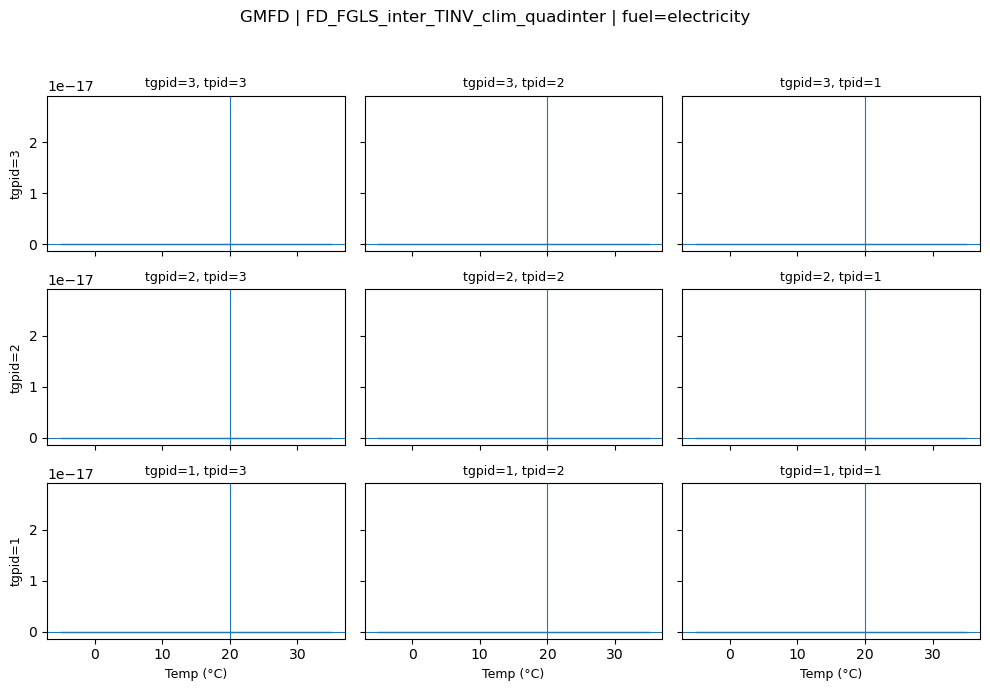


Done.


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
PROJECT = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")
REGD    = PROJECT / "data" / "regression"
STERD   = REGD / "sters"

# Original break_data from energy consumption release (as you used)
BREAK_DATA = Path(
    "/user/ab5405/summeraliaclimate/code/energy_consumption/"
    "energy_data_release_2021oct21/DATA/regression/break_data_TINV_clim.dta"
)

PRODUCT    = "GMFD"
MODEL_STEM = "FD_FGLS_inter_TINV_clim_quadinter"   # your exported stem
FUEL       = "electricity"                         # "electricity" or "other_energy"

COEF_PATH  = STERD / f"{MODEL_STEM}_{PRODUCT}_coeff.csv"

# Your regsort panel (must exist for anchor computation)
FD_PANEL   = REGD / f"{PRODUCT}_TINV_clim_regsort.dta"

# Plot toggle (leave True if you want the 3x3 plot)
MAKE_PLOT  = True

# Temperature grid (Stata plot grid is -5..35; keep it identical)
T = np.arange(-5, 36, 1.0)

# ============================================================
# SMALL HELPERS
# ============================================================
def must_exist(path: Path, label: str) -> None:
    ok = path.exists()
    print(f"{label}: {path}")
    print(f"  exists? {ok}")
    if not ok:
        raise FileNotFoundError(f"Missing {label}: {path}")

def read_coeff(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    if not {"parm", "beta"}.issubset(df.columns):
        raise ValueError(f"Expected columns ['parm','beta'] in {path}, got {df.columns.tolist()}")
    s = pd.Series(df["beta"].values, index=df["parm"].astype(str).values)
    return s

def breakdata_summary(bd: pd.DataFrame, fuel: str):
    print("\n--- break_data summary ---")
    print("rows:", len(bd))
    print("tpid unique:", sorted(pd.unique(bd["tpid"].dropna()).tolist()))
    print("tgpid unique:", sorted(pd.unique(bd["tgpid"].dropna()).tolist()))

    # Compute ibar (knot) the same way as Stata:
    maxcol  = f"maxInc_largegpid_{fuel}"
    flagcol = f"largegpid_{fuel}"
    if maxcol in bd.columns and flagcol in bd.columns:
        ibar = float(bd.loc[bd[flagcol] == 1, maxcol].max())
    else:
        ibar = np.nan

    # Use "first" after drop_duplicates to mimic their usage pattern
    celltab = bd.drop_duplicates(subset=["tpid", "tgpid"]).sort_values(["tpid", "tgpid"]).reset_index(drop=True)
    inc_map = celltab.groupby("tgpid")["avgInc_tgpid"].first().to_dict()
    cdd_map = celltab.groupby("tpid")["avgCDD_tpid"].first().to_dict()
    hdd_map = celltab.groupby("tpid")["avgHDD_tpid"].first().to_dict()

    # Clean printing
    inc_map = {int(k): float(v) for k, v in inc_map.items()}
    cdd_map = {int(k): float(v) for k, v in cdd_map.items()}
    hdd_map = {int(k): float(v) for k, v in hdd_map.items()}

    print("ibar_main:", ibar)
    print("Income terciles (tgpid -> avgInc_tgpid):", inc_map)
    print("CDD terciles (tpid -> avgCDD_tpid):", cdd_map)
    print("HDD terciles (tpid -> avgHDD_tpid):", hdd_map)

    return ibar, celltab, inc_map, cdd_map, hdd_map

def coef_name_check(coef: pd.Series):
    print("\n--- coeff CSV summary ---")
    print("n_coefs:", len(coef))

    want = [
        "c.indp1#c.indf1#c.FD_temp1",
        "c.indp1#c.indf1#c.FD_temp2",
        "c.indp1#c.indf1#c.FD_hdd20_TINVtemp1",
        "c.indp1#c.indf1#c.FD_hdd20_TINVtemp2",
        "c.indp1#c.indf1#c.FD_cdd20_TINVtemp1",
        "c.indp1#c.indf1#c.FD_cdd20_TINVtemp2",
    ]
    missing = [w for w in want if w not in coef.index]
    print("missing from core list:", missing)

    dc1 = sorted([p for p in coef.index if "FD_dc1_lgdppc_MA15" in p and "temp" in p])
    print("dc1 terms present (sample up to 12):")
    for p in dc1[:12]:
        print("  ", p)
    if len(dc1) > 12:
        print(f"  ... ({len(dc1)} total)")

def compute_anchor(panel_path: Path, fuel: str) -> float:
    dfp = pd.read_stata(panel_path)
    # Determine which largegpid column exists
    if "largegpid" in dfp.columns:
        lgflag = dfp["largegpid"]
    else:
        col = f"largegpid_{fuel}"
        if col not in dfp.columns:
            raise ValueError(f"Panel has no 'largegpid' or '{col}' column.")
        lgflag = dfp[col]

    if "product" not in dfp.columns:
        raise ValueError("Panel missing 'product' column (expected).")
    if "lgdppc_MA15" not in dfp.columns:
        raise ValueError("Panel missing 'lgdppc_MA15' column (expected).")

    sub = dfp[(dfp["product"] == fuel) & (lgflag == 1)]["lgdppc_MA15"]
    anchor = float(sub.max())
    print("\n--- regsort anchor ---")
    print("panel rows:", len(dfp))
    print("anchor max lgdppc_MA15 among largegpid==1 & product==fuel:", anchor)
    return anchor

def get_cell_covariates(celltab: pd.DataFrame, lg: int, tr: int):
    """
    Mimic original Stata indexing:
      tr_index = tr*3 -> row tr_index (1-based) in sorted celltab
      subInc from row lg (1-based) in same sorted celltab
    """
    tr_index_stata = tr * 3
    tr_row = tr_index_stata - 1
    lg_row = lg - 1

    subCDD = float(celltab.loc[tr_row, "avgCDD_tpid"])
    subHDD = float(celltab.loc[tr_row, "avgHDD_tpid"])
    subInc = float(celltab.loc[lg_row, "avgInc_tgpid"])
    return subInc, subCDD, subHDD

# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    # Existence checks
    must_exist(BREAK_DATA, "break_data")
    must_exist(COEF_PATH, "coeff CSV")
    must_exist(FD_PANEL, "regsort panel")

    # Load break_data
    bd = pd.read_stata(BREAK_DATA)
    ibar, celltab, inc_map, cdd_map, hdd_map = breakdata_summary(bd, FUEL)

    # Load coeffs
    coef = read_coeff(COEF_PATH)
    coef_name_check(coef)

    # Anchor from regsort panel (for debugging / documentation)
    anchor = compute_anchor(FD_PANEL, FUEL)

    # Optional: quick 3×3 plot (kept minimal, no normalization discussion)
    if MAKE_PLOT:
        print("\n--- making 3×3 plot ---")
        fig, axes = plt.subplots(3, 3, figsize=(10, 7), sharex=True, sharey=True)
        fig.suptitle(f"{PRODUCT} | {MODEL_STEM} | fuel={FUEL}", y=0.98)

        # Match Stata loop order: lg=3..1, tr=3..1
        for r, lg in enumerate([3, 2, 1]):
            for c, tr in enumerate([3, 2, 1]):
                subInc, subCDD, subHDD = get_cell_covariates(celltab, lg, tr)

                ax = axes[r, c]
                ax.plot(T, np.zeros_like(T), linewidth=1)  # placeholder baseline
                ax.axhline(0, linewidth=0.8)
                ax.axvline(20, linewidth=0.8)

                ax.set_title(f"tgpid={lg}, tpid={tr}", fontsize=9)
                if c == 0:
                    ax.set_ylabel(f"tgpid={lg}", fontsize=9)
                if r == 2:
                    ax.set_xlabel("Temp (°C)", fontsize=9)

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    print("\nDone.")


break_data: /user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression/break_data_TINV_clim.dta
  exists? True
coeff CSV: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_inter_TINV_clim_quadinter_GMFD_coeff.csv
  exists? True

--- break_data quick ---
rows: 4678
tpid unique: [1.0, 2.0, 3.0]
tgpid unique: [1.0, 2.0, 3.0]
ibar_main: 9.087010383605957

--- coeff CSV quick ---
n_coefs: 57
core missing: []


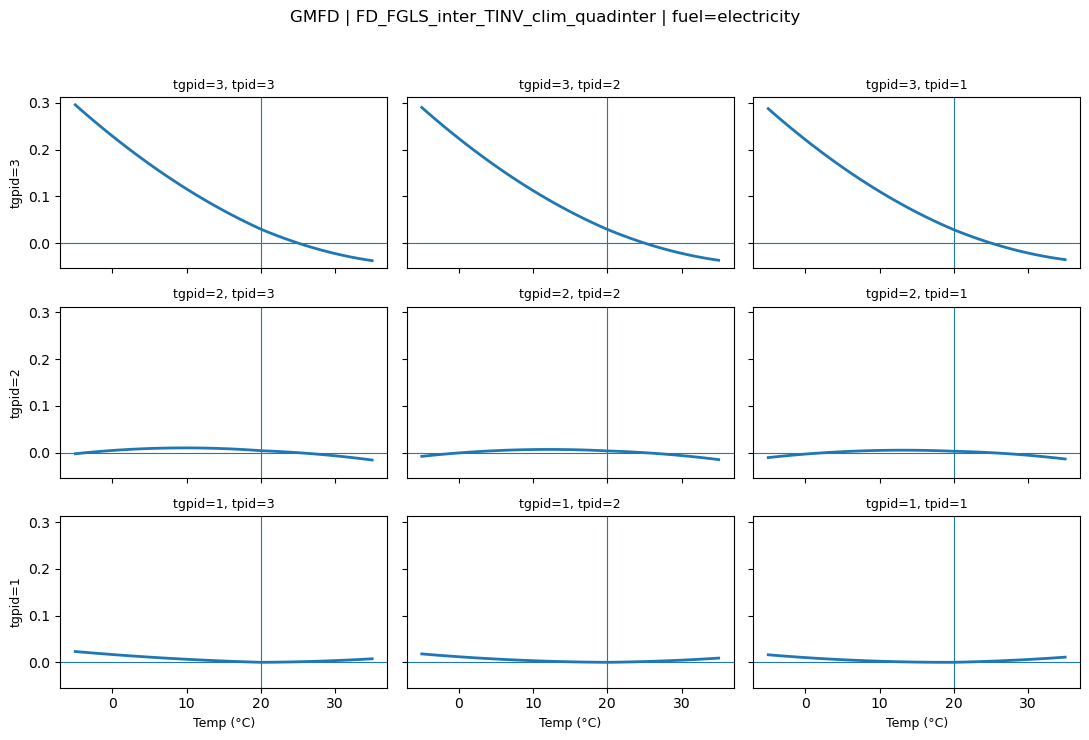


DEBUG (first cell meta):
{'tgpid': 3, 'tpid': 3, 'pg': 1, 'ig': 2, 'deltacut': 0.9102602005004883, 'subInc': 9.997270584106445, 'subCDD': 223.83596801757812, 'subHDD': 3925.80419921875}


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================
# CONFIG (matches your setup)
# ============================================================
PROJECT = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")
REGD    = PROJECT / "data" / "regression"
STERD   = REGD / "sters"

BREAK_DATA = Path(
    "/user/ab5405/summeraliaclimate/code/energy_consumption/"
    "energy_data_release_2021oct21/DATA/regression/break_data_TINV_clim.dta"
)

PRODUCT    = "GMFD"
MODEL_STEM = "FD_FGLS_inter_TINV_clim_quadinter"
FUEL       = "electricity"          # or "other_energy"
YEAR_PLOT  = 2099                   # same as Stata local year
IND_F      = 1                      # indf1 in your do-file

COEF_PATH  = STERD / f"{MODEL_STEM}_{PRODUCT}_coeff.csv"

# Temperature grid EXACTLY like Stata plot grid: -5..35 inclusive
T = np.arange(-5, 36, 1.0)
ABOVE20 = (T >= 20).astype(float)
BELOW20 = (T <  20).astype(float)

# Toggle: match your python runs (min over 10..25) if you want
DO_MIN_10_25 = True

# ============================================================
# IO + helpers
# ============================================================
def must_exist(path: Path, label: str) -> None:
    ok = path.exists()
    print(f"{label}: {path}")
    print(f"  exists? {ok}")
    if not ok:
        raise FileNotFoundError(f"Missing {label}: {path}")

def read_coeff(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    if not {"parm", "beta"}.issubset(df.columns):
        raise ValueError(f"Expected columns ['parm','beta'] in {path}, got {df.columns.tolist()}")
    return pd.Series(df["beta"].values, index=df["parm"].astype(str).values)

def ibar_from_breakdata(bd: pd.DataFrame, fuel: str) -> float:
    maxcol  = f"maxInc_largegpid_{fuel}"
    flagcol = f"largegpid_{fuel}"
    return float(bd.loc[bd[flagcol] == 1, maxcol].max())

def make_celltab(bd: pd.DataFrame) -> pd.DataFrame:
    # mimic Stata: duplicates drop tpid tgpid, force ; sort tpid tgpid
    return (bd.drop_duplicates(subset=["tpid", "tgpid"])
              .sort_values(["tpid", "tgpid"])
              .reset_index(drop=True))

def get_cell_covariates_simple(bd: pd.DataFrame, tgpid: int, tpid: int):
    # In your break_data, tpid/tgpid are 1..3 and means are constant within each group.
    # This is cleaner than the old "tr*3 indexing" from the paper release (which had 1..9).
    subInc = float(bd.loc[bd["tgpid"] == tgpid, "avgInc_tgpid"].mean())
    subCDD = float(bd.loc[bd["tpid"]  == tpid,  "avgCDD_tpid"].mean())
    subHDD = float(bd.loc[bd["tpid"]  == tpid,  "avgHDD_tpid"].mean())
    return subInc, subCDD, subHDD

def candidates(indp: int, indf: int, term: str, product: str) -> list[str]:
    # Try all naming variants you've actually seen in your coeff CSVs
    return [
        f"c.indp{indp}#c.indf{indf}#c.{term}_{product}",
        f"c.indp{indp}#c.indf{indf}#c.{term}",
        f"co.indp{indp}#co.indf{indf}#co.{term}_{product}",
        f"co.indp{indp}#co.indf{indf}#co.{term}",
    ]

def get_beta(coef: pd.Series, cand: list[str], default=0.0) -> float:
    for nm in cand:
        if nm in coef.index:
            return float(coef[nm])
    return float(default)

def response_curve_cell(coef: pd.Series, fuel: str, subInc: float, subCDD: float, subHDD: float,
                        ibar: float, year_plot: int, indf: int, product: str):
    # Stata:
    # if "`var'"=="electricity" local pg=1 else if other_energy local pg=2
    pg = 1 if fuel == "electricity" else 2

    # Stata income side
    ig = 2 if subInc > ibar else 1
    deltacut = float(subInc - ibar)   # IMPORTANT: Stata does NOT clip this

    y = np.zeros_like(T, dtype=float)

    for k in [1, 2]:
        Tk = T**k
        dT = Tk - (20.0**k)          # (temp^k - 20^k)
        dT_below = (20.0**k) - Tk    # (20^k - temp^k)

        # --- coefficients (try with and w/o _GMFD, c./co.) ---
        b_temp  = get_beta(coef, candidates(pg, indf, f"FD_temp{k}", product))

        b_cdd   = get_beta(coef, candidates(pg, indf, f"FD_cdd20_TINVtemp{k}", product))
        b_hdd   = get_beta(coef, candidates(pg, indf, f"FD_hdd20_TINVtemp{k}", product))

        # dc1 terms in your CSV appear without product suffix (but keep candidates() anyway)
        b_dc1   = get_beta(coef, candidates(pg, indf, f"FD_dc1_lgdppc_MA15I{ig}temp{k}", product))

        # year interactions (your CSV sometimes uses co.)
        b_yt    = get_beta(coef, candidates(pg, indf, f"FD_yeartemp{k}", product))
        b_dc1y  = get_beta(coef, candidates(pg, indf, f"FD_dc1_lgdppc_MA15yearI{ig}temp{k}", product))

        # year^2 interactions
        b_y2t   = get_beta(coef, candidates(pg, indf, f"FD_year2temp{k}", product))
        b_dc1y2 = get_beta(coef, candidates(pg, indf, f"FD_dc1_lgdppc_MA15year2I{ig}temp{k}", product))

        # --- assemble EXACTLY like Stata line ---
        y += b_temp * dT
        y += ABOVE20 * (b_cdd * subCDD * dT)
        y += BELOW20 * (b_hdd * subHDD * dT_below)
        y += b_dc1 * deltacut * dT

        y += b_yt   * dT * year_plot
        y += b_dc1y * deltacut * year_plot * dT

        y += b_y2t   * dT * (year_plot**2)
        y += b_dc1y2 * deltacut * (year_plot**2) * dT

    meta = dict(pg=pg, ig=ig, deltacut=deltacut, subInc=subInc, subCDD=subCDD, subHDD=subHDD)
    return y, meta

def min_10_25(y: np.ndarray) -> np.ndarray:
    m = (T >= 10) & (T <= 25)
    return y - np.min(y[m])

# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    must_exist(BREAK_DATA, "break_data")
    must_exist(COEF_PATH, "coeff CSV")

    bd = pd.read_stata(BREAK_DATA)
    ibar = ibar_from_breakdata(bd, FUEL)

    print("\n--- break_data quick ---")
    print("rows:", len(bd))
    print("tpid unique:", sorted(pd.unique(bd["tpid"]).tolist()))
    print("tgpid unique:", sorted(pd.unique(bd["tgpid"]).tolist()))
    print("ibar_main:", ibar)

    coef = read_coeff(COEF_PATH)
    print("\n--- coeff CSV quick ---")
    print("n_coefs:", len(coef))
    # sanity: core names present
    core = [
        "c.indp1#c.indf1#c.FD_temp1",
        "c.indp1#c.indf1#c.FD_temp2",
        "c.indp1#c.indf1#c.FD_hdd20_TINVtemp1",
        "c.indp1#c.indf1#c.FD_cdd20_TINVtemp1",
    ]
    missing = [x for x in core if x not in coef.index]
    print("core missing:", missing)

    # ========================================================
    # Plot 3×3 (rows: tgpid=3..1 ; cols: tpid=3..1)
    # ========================================================
    fig, axes = plt.subplots(3, 3, figsize=(11, 7.5), sharex=True, sharey=True)
    fig.suptitle(f"{PRODUCT} | {MODEL_STEM} | fuel={FUEL}", y=0.98)

    first_meta = None

    for r, tgpid in enumerate([3, 2, 1]):      # income: high -> low
        for c, tpid in enumerate([3, 2, 1]):   # climate: cold -> hot (consistent with your earlier interpretation)
            subInc, subCDD, subHDD = get_cell_covariates_simple(bd, tgpid=tgpid, tpid=tpid)
            y, meta = response_curve_cell(
                coef=coef, fuel=FUEL, subInc=subInc, subCDD=subCDD, subHDD=subHDD,
                ibar=ibar, year_plot=YEAR_PLOT, indf=IND_F, product=PRODUCT
            )

            if DO_MIN_10_25:
                y = min_10_25(y)

            ax = axes[r, c]
            ax.plot(T, y, linewidth=2)
            ax.axhline(0, linewidth=0.8)
            ax.axvline(20, linewidth=0.8)

            ax.set_title(f"tgpid={tgpid}, tpid={tpid}", fontsize=9)
            if c == 0:
                ax.set_ylabel(f"tgpid={tgpid}", fontsize=9)
            if r == 2:
                ax.set_xlabel("Temp (°C)", fontsize=9)

            if first_meta is None:
                first_meta = {"tgpid": tgpid, "tpid": tpid, **meta}

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    print("\nDEBUG (first cell meta):")
    print(first_meta)


break_data: /user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression/break_data_TINV_clim.dta | exists? True
original regsort panel: /user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression/GMFD_TINV_clim_regsort.dta | exists? True
NEW coeff csv: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_inter_TINV_clim_quadinter_GMFD_coeff.csv | exists? True
ORIGINAL coeff csv (export from .ster if needed): /user/ab5405/summeraliaclimate/code/energy_uncertainty/output_original/sters/FD_FGLS_inter_TINV_clim_quadinter_coeff.csv | exists? True

ibar_main: 9.087010383605957

NEW n_coefs: 57
OLD n_coefs: 57

Wrote: /user/ab5405/summeraliaclimate/code/energy_uncertainty/figures/python_compare/coef_compare_FD_FGLS_inter_TINV_clim_quadinter_electricity.csv
Wrote: /user/ab5405/summeraliaclimate/code/energy_uncertainty/figures/python_compare/coef_compare_FD_FGLS_inter_TINV_clim_quad

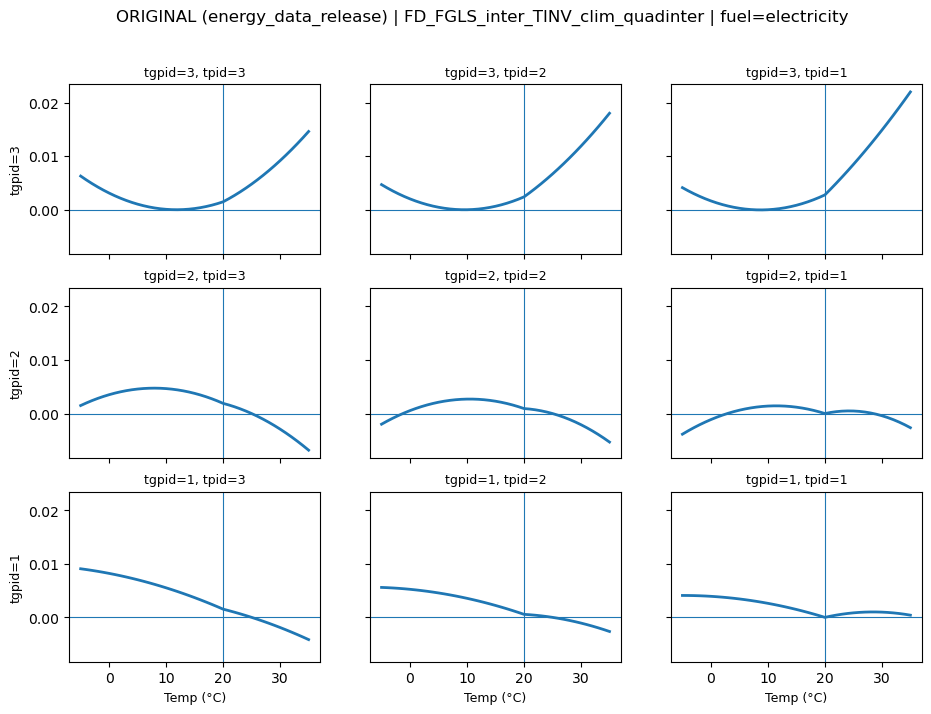

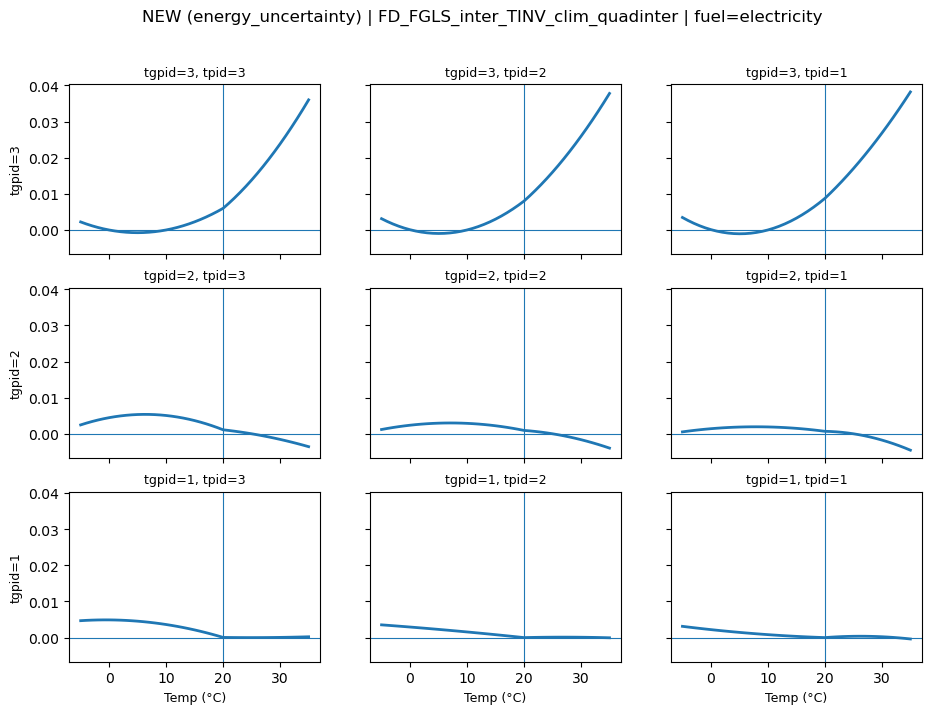

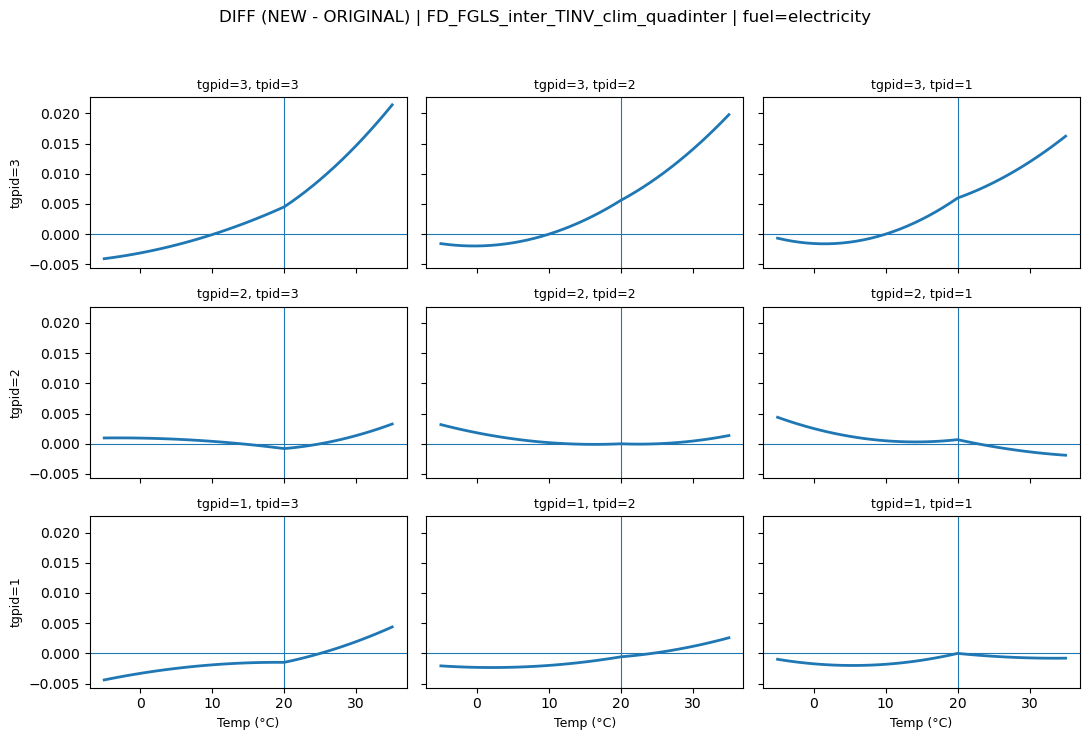

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================
EU = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")

NEW_STERD = EU / "data" / "regression" / "sters"
OLD_STERD = EU / "output_original" / "sters"

# original release panels + break_data
EDR = Path("/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression")
BREAK_DATA = EDR / "break_data_TINV_clim.dta"
ORIG_PANEL = EDR / "GMFD_TINV_clim_regsort.dta"

# ============================================================
# SETTINGS
# ============================================================
PRODUCT = "GMFD"
FUEL = "electricity"            # or "other_energy"
YEAR_PLOT = 2010
IND_F = 1

MODEL_STEM = "FD_FGLS_inter_TINV_clim_quadinter"  # base stem
FILE_STEM = f"{MODEL_STEM}"

NEW_COEF = NEW_STERD / f"{FILE_STEM}_{PRODUCT}_coeff.csv"
OLD_COEF =  EU / "output_original" / "sters" / f"{FILE_STEM}_coeff.csv"  # after export step above

# Temperature grid (match Stata)
T = np.arange(-5, 36, 1.0)
ABOVE20 = (T >= 20).astype(float)
BELOW20 = (T < 20).astype(float)

# Toggle normalization (you were doing this; keep it as a flag)
NORMALIZE_MIN_10_25 = True

# ============================================================
# HELPERS
# ============================================================
def must_exist(path: Path, label: str):
    ok = path.exists()
    print(f"{label}: {path} | exists? {ok}")
    if not ok:
        raise FileNotFoundError(f"Missing {label}: {path}")

def read_coeff(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    if not {"parm", "beta"}.issubset(df.columns):
        raise ValueError(f"Expected columns parm,beta in {path}. Got: {df.columns.tolist()}")
    return pd.Series(df["beta"].values, index=df["parm"].astype(str).values)

def ibar_from_breakdata(bd: pd.DataFrame, fuel: str) -> float:
    maxcol = f"maxInc_largegpid_{fuel}"
    flagcol = f"largegpid_{fuel}"
    return float(bd.loc[bd[flagcol] == 1, maxcol].max())

def get_cell_covariates_simple(bd: pd.DataFrame, tgpid: int, tpid: int):
    # break_data here uses tpid,tgpid in {1,2,3}
    subInc = float(bd.loc[bd["tgpid"] == tgpid, "avgInc_tgpid"].mean())
    subCDD = float(bd.loc[bd["tpid"]  == tpid,  "avgCDD_tpid"].mean())
    subHDD = float(bd.loc[bd["tpid"]  == tpid,  "avgHDD_tpid"].mean())
    return subInc, subCDD, subHDD

def candidates(indp: int, indf: int, term: str, product: str) -> list[str]:
    # try observed naming variants
    return [
        f"c.indp{indp}#c.indf{indf}#c.{term}_{product}",
        f"c.indp{indp}#c.indf{indf}#c.{term}",
        f"co.indp{indp}#co.indf{indf}#co.{term}_{product}",
        f"co.indp{indp}#co.indf{indf}#co.{term}",
    ]

def get_beta(coef: pd.Series, cand: list[str], default=0.0) -> float:
    for nm in cand:
        if nm in coef.index:
            return float(coef[nm])
    return float(default)

def yhat_curve(coef: pd.Series, fuel: str, subInc: float, subCDD: float, subHDD: float,
               ibar: float, year_plot: int, indf: int, product: str):
    # pg mapping
    pg = 1 if fuel == "electricity" else 2
    ig = 2 if subInc > ibar else 1
    deltacut = float(subInc - ibar)   # match Stata (NOT clipped)

    y = np.zeros_like(T, dtype=float)

    for k in [1, 2]:
        Tk = T**k
        dT = Tk - (20.0**k)
        dT_below = (20.0**k) - Tk

        b_temp  = get_beta(coef, candidates(pg, indf, f"FD_temp{k}", product))
        b_cdd   = get_beta(coef, candidates(pg, indf, f"FD_cdd20_TINVtemp{k}", product))
        b_hdd   = get_beta(coef, candidates(pg, indf, f"FD_hdd20_TINVtemp{k}", product))

        b_dc1   = get_beta(coef, candidates(pg, indf, f"FD_dc1_lgdppc_MA15I{ig}temp{k}", product))
        b_yt    = get_beta(coef, candidates(pg, indf, f"FD_yeartemp{k}", product))
        b_dc1y  = get_beta(coef, candidates(pg, indf, f"FD_dc1_lgdppc_MA15yearI{ig}temp{k}", product))
        b_y2t   = get_beta(coef, candidates(pg, indf, f"FD_year2temp{k}", product))
        b_dc1y2 = get_beta(coef, candidates(pg, indf, f"FD_dc1_lgdppc_MA15year2I{ig}temp{k}", product))

        # assemble like Stata
        y += b_temp * dT
        y += ABOVE20 * (b_cdd * subCDD * dT)
        y += BELOW20 * (b_hdd * subHDD * dT_below)
        y += b_dc1 * deltacut * dT

        y += b_yt * dT * year_plot
        y += b_dc1y * deltacut * year_plot * dT

        y += b_y2t * dT * (year_plot**2)
        y += b_dc1y2 * deltacut * (year_plot**2) * dT

    if NORMALIZE_MIN_10_25:
        m = (T >= 10) & (T <= 25)
        y = y - np.min(y[m])

    return y

def coef_compare_table(coef_old: pd.Series, coef_new: pd.Series) -> pd.DataFrame:
    idx = sorted(set(coef_old.index).union(set(coef_new.index)))
    out = pd.DataFrame({"parm": idx})
    out["beta_old"] = out["parm"].map(coef_old).astype(float)
    out["beta_new"] = out["parm"].map(coef_new).astype(float)
    out["diff"] = out["beta_new"] - out["beta_old"]
    out["abs_diff"] = out["diff"].abs()
    out["rel_diff_pct"] = np.where(out["beta_old"].abs() > 0, 100*out["diff"]/out["beta_old"], np.nan)
    out = out.sort_values("abs_diff", ascending=False).reset_index(drop=True)
    return out

# ============================================================
# RUN
# ============================================================
must_exist(BREAK_DATA, "break_data")
must_exist(ORIG_PANEL, "original regsort panel")
must_exist(NEW_COEF, "NEW coeff csv")
must_exist(OLD_COEF, "ORIGINAL coeff csv (export from .ster if needed)")

bd = pd.read_stata(BREAK_DATA)
ibar = ibar_from_breakdata(bd, FUEL)
print("\nibar_main:", ibar)

coef_new = read_coeff(NEW_COEF)
coef_old = read_coeff(OLD_COEF)

print("\nNEW n_coefs:", len(coef_new))
print("OLD n_coefs:", len(coef_old))

# ---- Pretty coefficient diff table
cmp = coef_compare_table(coef_old, coef_new)

OUTDIR = EU / "figures" / "python_compare"
OUTDIR.mkdir(parents=True, exist_ok=True)

cmp_csv  = OUTDIR / f"coef_compare_{FILE_STEM}_{FUEL}.csv"
cmp_html = OUTDIR / f"coef_compare_{FILE_STEM}_{FUEL}.html"
cmp.to_csv(cmp_csv, index=False)

# quick HTML (nice for Kevin)
cmp.head(80).to_html(cmp_html, index=False)
print("\nWrote:", cmp_csv)
print("Wrote:", cmp_html, "(top 80 rows)")

# ---- 3×3 plots: ORIGINAL vs NEW + difference
fig, axes = plt.subplots(3, 3, figsize=(11, 7.5), sharex=True, sharey=True)
fig.suptitle(f"ORIGINAL (energy_data_release) | {FILE_STEM} | fuel={FUEL}", y=0.98)

fig2, axes2 = plt.subplots(3, 3, figsize=(11, 7.5), sharex=True, sharey=True)
fig2.suptitle(f"NEW (energy_uncertainty) | {FILE_STEM} | fuel={FUEL}", y=0.98)

fig3, axes3 = plt.subplots(3, 3, figsize=(11, 7.5), sharex=True, sharey=True)
fig3.suptitle(f"DIFF (NEW - ORIGINAL) | {FILE_STEM} | fuel={FUEL}", y=0.98)

for r, tgpid in enumerate([3, 2, 1]):
    for c, tpid in enumerate([3, 2, 1]):
        subInc, subCDD, subHDD = get_cell_covariates_simple(bd, tgpid=tgpid, tpid=tpid)

        y_old = yhat_curve(coef_old, FUEL, subInc, subCDD, subHDD, ibar, YEAR_PLOT, IND_F, PRODUCT)
        y_new = yhat_curve(coef_new, FUEL, subInc, subCDD, subHDD, ibar, YEAR_PLOT, IND_F, PRODUCT)
        y_dif = y_new - y_old

        ax = axes[r, c]
        ax.plot(T, y_old, linewidth=2)
        ax.axhline(0, linewidth=0.8)
        ax.axvline(20, linewidth=0.8)
        ax.set_title(f"tgpid={tgpid}, tpid={tpid}", fontsize=9)
        if c == 0: ax.set_ylabel(f"tgpid={tgpid}", fontsize=9)
        if r == 2: ax.set_xlabel("Temp (°C)", fontsize=9)

        ax2 = axes2[r, c]
        ax2.plot(T, y_new, linewidth=2)
        ax2.axhline(0, linewidth=0.8)
        ax2.axvline(20, linewidth=0.8)
        ax2.set_title(f"tgpid={tgpid}, tpid={tpid}", fontsize=9)
        if c == 0: ax2.set_ylabel(f"tgpid={tgpid}", fontsize=9)
        if r == 2: ax2.set_xlabel("Temp (°C)", fontsize=9)

        ax3 = axes3[r, c]
        ax3.plot(T, y_dif, linewidth=2)
        ax3.axhline(0, linewidth=0.8)
        ax3.axvline(20, linewidth=0.8)
        ax3.set_title(f"tgpid={tgpid}, tpid={tpid}", fontsize=9)
        if c == 0: ax3.set_ylabel(f"tgpid={tgpid}", fontsize=9)
        if r == 2: ax3.set_xlabel("Temp (°C)", fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.tight_layout(rect=[0, 0, 1, 0.95])

pdf_old = OUTDIR / f"plot3x3_ORIGINAL_{FILE_STEM}_{FUEL}.pdf"
pdf_new = OUTDIR / f"plot3x3_NEW_{FILE_STEM}_{FUEL}.pdf"
pdf_dif = OUTDIR / f"plot3x3_DIFF_{FILE_STEM}_{FUEL}.pdf"

fig.savefig(pdf_old)
fig2.savefig(pdf_new)
fig3.savefig(pdf_dif)

print("\nSaved:", pdf_old)
print("Saved:", pdf_new)
print("Saved:", pdf_dif)

plt.show()


break_data: /user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression/break_data_TINV_clim.dta | exists? True
ibar_main: 9.087010383605957
GMFD coeff: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_inter_TINV_clim_quadinter_GMFD_coeff.csv | exists? True
[INFO] Loaded VCV for GMFD: (57, 57)
ERA5 coeff: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_inter_TINV_clim_quadinter_ERA5_coeff.csv | exists? True
[INFO] Loaded VCV for ERA5: (57, 57)
JRA_3Q coeff: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_inter_TINV_clim_quadinter_JRA_3Q_coeff.csv | exists? True
[INFO] Loaded VCV for JRA_3Q: (57, 57)
MERRA2 coeff: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_inter_TINV_clim_quadinter_MERRA2_coeff.csv | exists? True
[INFO] Loaded VCV for MERRA2: (57, 57)

Starting 3x3 plot generation...

    [MC WARN

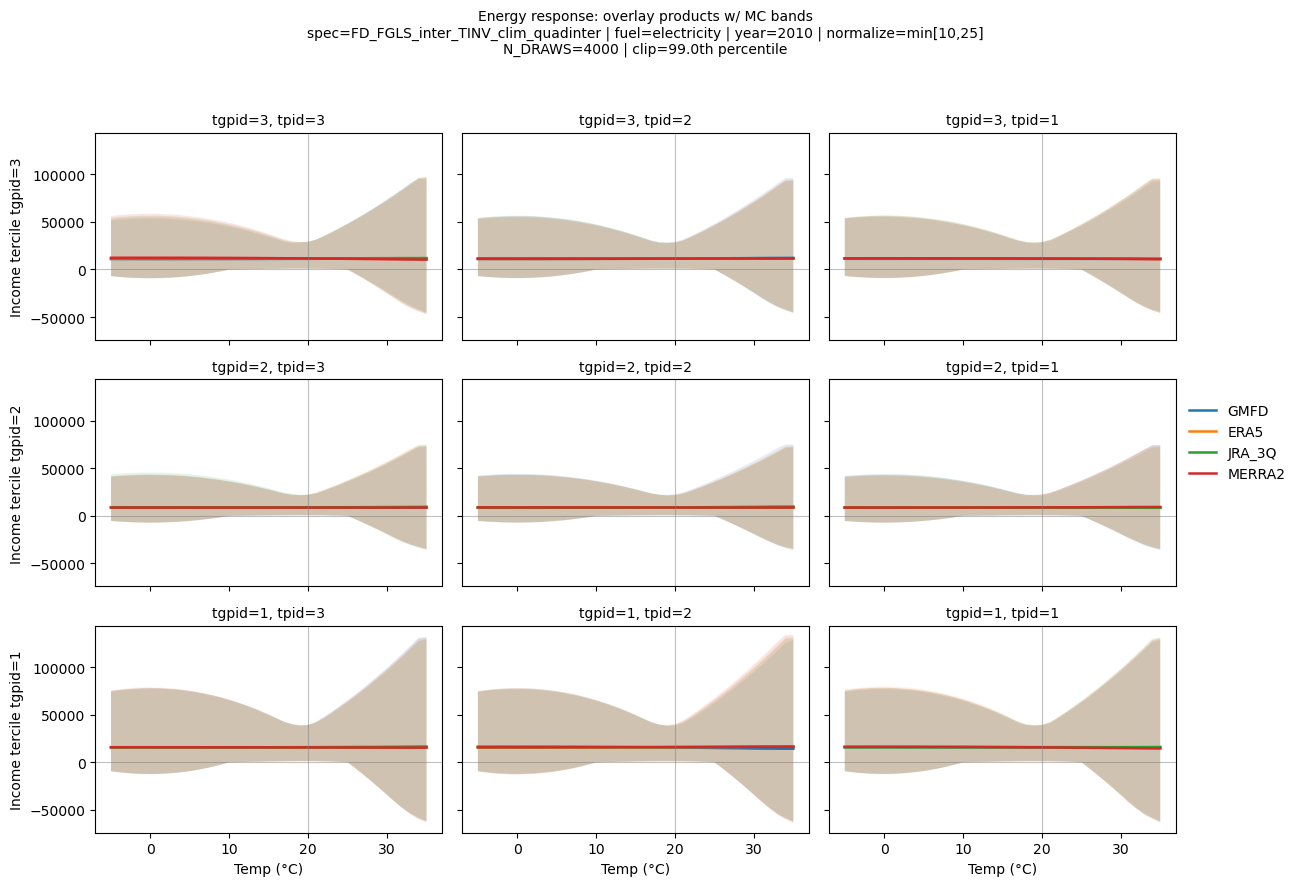

In [28]:
"""
FIXED VERSION: Monte Carlo bands with anti-blowup safeguards

KEY FIXES FROM YOUR ORIGINAL SCRIPT:
1. Added CLIP_PERCENTILE parameter (99.0) - clips extreme draws BEFORE normalization
2. Added vcov matrix validation (symmetry, PSD, ridge regularization)
3. Added detailed diagnostics (set VERBOSE_MC=True to see what's happening)
4. Added sanity checks for band width
5. Better error handling with fallback to point estimates

QUICK TROUBLESHOOTING:
- If bands still blow up: reduce CLIP_PERCENTILE to 97 or 95
- If bands are too narrow: increase CLIP_PERCENTILE to 99.5 or 99.9
- If you want to see diagnostics: set VERBOSE_MC = True
- If year=2099 is problematic: change YEAR_PLOT to 2010

The key insight: clipping happens BEFORE normalization, which prevents
extreme draws from dominating the min() operation in normalization.
"""

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================
EU = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")

NEW_STERD = EU / "data" / "regression" / "sters"
OLD_STERD = EU / "output_original" / "sters"

EDR = Path("/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression")
BREAK_DATA = EDR / "break_data_TINV_clim.dta"

# ============================================================
# SETTINGS
# ============================================================
PRODUCTS = ["GMFD", "ERA5", "JRA_3Q", "MERRA2"]
FUEL = "electricity"                  # or "other_energy"
IND_F = 1
YEAR_PLOT = 2010

# Choose spec; lininter is easier/stabler if quadinter VCV is borked
# MODEL_STEM = "FD_FGLS_inter_TINV_clim_lininter"
MODEL_STEM = "FD_FGLS_inter_TINV_clim_quadinter"

# Temperature grid (match Stata)
T = np.arange(-5, 36, 1.0)
ABOVE20 = (T >= 20).astype(float)
BELOW20 = (T < 20).astype(float)

NORMALIZE_MIN_10_25 = True
SLICE_MIN, SLICE_MAX = 10, 25

# MC settings
N_DRAWS = 4000
SEED = 123
CLIP_PERCENTILE = 99.0  # CRITICAL: clip extreme draws to prevent blowup
VERBOSE_MC = False      # Set to True to see MC diagnostics

# Output
OUTDIR = EU / "figures" / "python_compare"
OUTDIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================
def must_exist(path: Path, label: str):
    ok = path.exists()
    print(f"{label}: {path} | exists? {ok}")
    if not ok:
        raise FileNotFoundError(f"Missing {label}: {path}")

def read_coeff_csv(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    if not {"parm", "beta"}.issubset(df.columns):
        raise ValueError(f"Expected columns parm,beta in {path}. Got {df.columns.tolist()}")
    return pd.Series(df["beta"].values, index=df["parm"].astype(str).values)

def read_vcov_long_csv(path: Path) -> pd.DataFrame:
    """
    Expects columns: parm_i, parm_j, v (your export format)
    Returns square DataFrame V with index/cols as parameter names.
    """
    df = pd.read_csv(path)
    need = {"parm_i", "parm_j", "v"}
    if not need.issubset(df.columns):
        raise ValueError(f"Expected columns {need} in {path}. Got {df.columns.tolist()}")

    # Pivot to square
    V = df.pivot(index="parm_i", columns="parm_j", values="v")
    V = V.astype(float)

    # Fill missing with 0 then symmetrize a bit (numerical hygiene)
    V = V.fillna(0.0)
    # Ensure symmetry if only one triangle exported imperfectly
    V = (V + V.T) / 2.0
    return V

def ibar_from_breakdata(bd: pd.DataFrame, fuel: str) -> float:
    maxcol = f"maxInc_largegpid_{fuel}"
    flagcol = f"largegpid_{fuel}"
    return float(bd.loc[bd[flagcol] == 1, maxcol].max())

def get_cell_covariates(bd: pd.DataFrame, tgpid: int, tpid: int):
    """
    Use the tercile means from break_data.
    (Your earlier print confirms tpid,tgpid are exactly 1..3)
    """
    subInc = float(bd.loc[bd["tgpid"] == tgpid, "avgInc_tgpid"].mean())
    subCDD = float(bd.loc[bd["tpid"]  == tpid,  "avgCDD_tpid"].mean())
    subHDD = float(bd.loc[bd["tpid"]  == tpid,  "avgHDD_tpid"].mean())
    return subInc, subCDD, subHDD

def name_candidates(pg: int, indf: int, term: str, product: str) -> list[str]:
    """
    Try the naming variants you've seen:
      - c. / co.
      - with and without _PRODUCT suffix
    """
    return [
        f"c.indp{pg}#c.indf{indf}#c.{term}_{product}",
        f"c.indp{pg}#c.indf{indf}#c.{term}",
        f"co.indp{pg}#co.indf{indf}#co.{term}_{product}",
        f"co.indp{pg}#co.indf{indf}#co.{term}",
    ]

def resolve_name(coef: pd.Series, pg: int, indf: int, term: str, product: str) -> str | None:
    for nm in name_candidates(pg, indf, term, product):
        if nm in coef.index:
            return nm
    return None

def build_design_and_names(coef: pd.Series, fuel: str, product: str, tgpid: int, tpid: int,
                           subInc: float, subCDD: float, subHDD: float, ibar: float,
                           year_plot: int, indf: int):
    """
    Build y(T) as y = X(T) @ beta_used, where beta_used is a vector of
    selected coefficient elements from the full model.

    Returns:
      names_used: list[str]
      X: ndarray (len(T), p)
      meta: dict with pg, ig, deltacut
    """
    pg = 1 if fuel == "electricity" else 2
    ig = 2 if subInc > ibar else 1
    deltacut = float(subInc - ibar)  # matches Stata (NOT clipped)

    names_used = []
    cols = []  # list of arrays length len(T) (each is regressor column)

    for k in [1, 2]:
        Tk = T**k
        dT = Tk - (20.0**k)
        dT_below = (20.0**k) - Tk

        # required core
        nm_temp = resolve_name(coef, pg, indf, f"FD_temp{k}", product)
        nm_cdd  = resolve_name(coef, pg, indf, f"FD_cdd20_TINVtemp{k}", product)
        nm_hdd  = resolve_name(coef, pg, indf, f"FD_hdd20_TINVtemp{k}", product)

        # income spline (no suffix in many exports, but our resolver handles both)
        nm_dc1  = resolve_name(coef, pg, indf, f"FD_dc1_lgdppc_MA15I{ig}temp{k}", product)

        # year interactions (resolver handles c./co.)
        nm_yt   = resolve_name(coef, pg, indf, f"FD_yeartemp{k}", product)
        nm_dc1y = resolve_name(coef, pg, indf, f"FD_dc1_lgdppc_MA15yearI{ig}temp{k}", product)

        # quadinter extras
        nm_y2t   = resolve_name(coef, pg, indf, f"FD_year2temp{k}", product)
        nm_dc1y2 = resolve_name(coef, pg, indf, f"FD_dc1_lgdppc_MA15year2I{ig}temp{k}", product)

        # temp
        if nm_temp is not None:
            names_used.append(nm_temp)
            cols.append(dT)

        # CDD gated
        if nm_cdd is not None:
            names_used.append(nm_cdd)
            cols.append(ABOVE20 * subCDD * dT)

        # HDD gated (note Stata uses (20^k - temp^k))
        if nm_hdd is not None:
            names_used.append(nm_hdd)
            cols.append(BELOW20 * subHDD * dT_below)

        # dc1 spline
        if nm_dc1 is not None:
            names_used.append(nm_dc1)
            cols.append(deltacut * dT)

        # year terms (lininter + quadinter)
        if nm_yt is not None:
            names_used.append(nm_yt)
            cols.append(year_plot * dT)

        if nm_dc1y is not None:
            names_used.append(nm_dc1y)
            cols.append(deltacut * year_plot * dT)

        # year^2 terms (quadinter)
        if nm_y2t is not None:
            names_used.append(nm_y2t)
            cols.append((year_plot**2) * dT)

        if nm_dc1y2 is not None:
            names_used.append(nm_dc1y2)
            cols.append(deltacut * (year_plot**2) * dT)

    if len(names_used) == 0:
        raise RuntimeError("No coefficients were resolved into a design matrix. Check naming.")

    X = np.column_stack(cols)  # (len(T), p)
    meta = {"pg": pg, "ig": ig, "deltacut": deltacut, "tgpid": tgpid, "tpid": tpid}
    return names_used, X, meta

def curve_from_beta(beta_vec: np.ndarray, X: np.ndarray) -> np.ndarray:
    y = X @ beta_vec
    if NORMALIZE_MIN_10_25:
        win = (T >= SLICE_MIN) & (T <= SLICE_MAX)
        y = y - np.min(y[win])
    return y

def mc_bands(beta_mean: np.ndarray, beta_cov: np.ndarray, X: np.ndarray, 
             n_draws: int, seed: int, clip_percentile: float = 99.0):
    """
    Draw beta ~ N(beta_mean, beta_cov) and compute y(T) draws.
    Returns mean curve + 5/95 bands.
    
    CRITICAL SAFEGUARDS AGAINST BLOWUP:
    1. Regularize vcov matrix to ensure it's PSD
    2. Clip extreme raw predictions before normalization
    3. Normalize by subtracting min in [SLICE_MIN, SLICE_MAX]
    """
    rng = np.random.default_rng(seed)

    # SAFEGUARD 1: Regularize vcov to prevent numerical issues
    eps = 1e-10
    beta_cov_reg = beta_cov.copy()
    
    # Force symmetry
    if not np.allclose(beta_cov_reg, beta_cov_reg.T):
        if VERBOSE_MC:
            print("    [MC] Forcing vcov symmetry")
        beta_cov_reg = (beta_cov_reg + beta_cov_reg.T) / 2.0
    
    # Add small ridge to diagonal to ensure PSD
    eigvals = np.linalg.eigvalsh(beta_cov_reg)
    if eigvals.min() < 0:
        if VERBOSE_MC:
            print(f"    [MC] Negative eigenvalues detected (min={eigvals.min():.2e}), adding ridge")
        beta_cov_reg.flat[::beta_cov_reg.shape[0] + 1] += abs(eigvals.min()) + eps
    else:
        # Always add tiny ridge for numerical stability
        beta_cov_reg.flat[::beta_cov_reg.shape[0] + 1] += eps

    # Draw from multivariate normal
    try:
        draws = rng.multivariate_normal(beta_mean, beta_cov_reg, size=n_draws)  # (n, p)
    except np.linalg.LinAlgError as e:
        print(f"    [MC ERROR] Failed to draw from MVN: {e}")
        print(f"    [MC ERROR] Falling back to point estimate only")
        y_point = curve_from_beta(beta_mean, X)
        return y_point, y_point, y_point
    
    # Compute raw predictions
    y_draws = draws @ X.T  # (n, len(T))

    # SAFEGUARD 2: Clip extreme predictions BEFORE normalization
    # This is THE KEY to preventing blowup
    if clip_percentile is not None and clip_percentile < 100:
        # Compute clipping bounds based on absolute values across all draws and temps
        clip_max = np.percentile(np.abs(y_draws), clip_percentile)
        
        # Check if we're clipping a significant amount
        n_clipped = np.sum(np.abs(y_draws) > clip_max)
        pct_clipped = 100 * n_clipped / y_draws.size
        
        if VERBOSE_MC and pct_clipped > 0.5:
            print(f"    [MC] Clipping {pct_clipped:.1f}% of predictions at {clip_percentile}th percentile")
            print(f"    [MC] Clip threshold: ±{clip_max:.2e}")
            print(f"    [MC] Raw range before clip: [{y_draws.min():.2e}, {y_draws.max():.2e}]")
        
        # Apply clipping
        y_draws = np.clip(y_draws, -clip_max, clip_max)
        
        if VERBOSE_MC:
            print(f"    [MC] Range after clip: [{y_draws.min():.2e}, {y_draws.max():.2e}]")

    # SAFEGUARD 3: Normalize by subtracting min in [SLICE_MIN, SLICE_MAX]
    # This removes level shift uncertainty that causes bands to explode
    if NORMALIZE_MIN_10_25:
        win = (T >= SLICE_MIN) & (T <= SLICE_MAX)
        base = np.min(y_draws[:, win], axis=1)  # (n_draws,)
        y_draws = y_draws - base[:, None]
        
        if VERBOSE_MC:
            print(f"    [MC] Range after normalization: [{y_draws.min():.2e}, {y_draws.max():.2e}]")

    # Compute summary statistics
    y_mean = y_draws.mean(axis=0)
    y_lo, y_hi = np.percentile(y_draws, [5, 95], axis=0)
    
    # Final sanity check: if bands are still extreme, something is wrong
    band_width = np.max(y_hi - y_lo)
    if band_width > 1000:
        print(f"    [MC WARNING] Extremely wide confidence bands detected (width={band_width:.2e})")
        print(f"    [MC WARNING] Consider using year_plot=2010 instead of {YEAR_PLOT}")
        print(f"    [MC WARNING] Or reduce CLIP_PERCENTILE (currently {clip_percentile})")
    
    return y_mean, y_lo, y_hi

# ============================================================
# LOAD break_data once
# ============================================================
must_exist(BREAK_DATA, "break_data")
bd = pd.read_stata(BREAK_DATA)
ibar = ibar_from_breakdata(bd, FUEL)
print("ibar_main:", ibar)

# ============================================================
# MULTI-PRODUCT MC OVERLAY: 3×3
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True, sharey=True)
fig.suptitle(
    f"Energy response: overlay products w/ MC bands\n"
    f"spec={MODEL_STEM} | fuel={FUEL} | year={YEAR_PLOT} | normalize=min[{SLICE_MIN},{SLICE_MAX}]\n"
    f"N_DRAWS={N_DRAWS} | clip={CLIP_PERCENTILE}th percentile",
    y=0.98, fontsize=10
)

# Pre-load coefs + VCVs for each product
product_data = {}
for prod in PRODUCTS:
    coef_path = NEW_STERD / f"{MODEL_STEM}_{prod}_coeff.csv"
    vcov_path = NEW_STERD / f"{MODEL_STEM}_{prod}_vcov_long.csv"

    must_exist(coef_path, f"{prod} coeff")
    coef = read_coeff_csv(coef_path)

    V = None
    if vcov_path.exists():
        try:
            V = read_vcov_long_csv(vcov_path)
            print(f"[INFO] Loaded VCV for {prod}: {V.shape}")
        except Exception as e:
            print(f"[WARN] Could not read VCV for {prod}: {e}")
            V = None
    else:
        print(f"[WARN] Missing VCV for {prod}: {vcov_path}")

    product_data[prod] = {"coef": coef, "V": V}

print(f"\n{'='*60}")
print(f"Starting 3x3 plot generation...")
print(f"{'='*60}\n")

# Plot order matches your Stata: rows tgpid=3..1, cols tpid=3..1
for r, tgpid in enumerate([3, 2, 1]):
    for c, tpid in enumerate([3, 2, 1]):
        if VERBOSE_MC:
            print(f"Cell ({tgpid}, {tpid}):")
        
        ax = axes[r, c]
        subInc, subCDD, subHDD = get_cell_covariates(bd, tgpid=tgpid, tpid=tpid)

        # Overlay each product
        for prod in PRODUCTS:
            if VERBOSE_MC:
                print(f"  Product: {prod}")
            
            coef = product_data[prod]["coef"]
            Vfull = product_data[prod]["V"]

            # Build X and the coefficient subvector used
            names_used, X, meta = build_design_and_names(
                coef=coef,
                fuel=FUEL,
                product=prod,
                tgpid=tgpid,
                tpid=tpid,
                subInc=subInc,
                subCDD=subCDD,
                subHDD=subHDD,
                ibar=ibar,
                year_plot=YEAR_PLOT,
                indf=IND_F,
            )

            beta_mean = np.array([float(coef[nm]) for nm in names_used], dtype=float)

            # If we have a VCV, extract the matching submatrix; else just plot mean
            if Vfull is not None:
                # Align submatrix to names_used, missing entries -> 0
                Vsub = Vfull.reindex(index=names_used, columns=names_used).fillna(0.0).to_numpy()
                
                # If Vsub is all zeros (your quadinter bug), fall back to mean-only
                if np.allclose(Vsub, 0.0):
                    if VERBOSE_MC:
                        print(f"    [WARN] VCV submatrix is all zeros, plotting point estimate only")
                    y = curve_from_beta(beta_mean, X)
                    ax.plot(T, y, linewidth=1.8, label=prod)
                else:
                    # Compute MC bands with safeguards
                    y_mean, y_lo, y_hi = mc_bands(
                        beta_mean, Vsub, X, 
                        n_draws=N_DRAWS, 
                        seed=SEED + hash((prod, tgpid, tpid)) % 100000,
                        clip_percentile=CLIP_PERCENTILE
                    )
                    ax.fill_between(T, y_lo, y_hi, alpha=0.12)
                    ax.plot(T, y_mean, linewidth=1.8, label=prod)
            else:
                y = curve_from_beta(beta_mean, X)
                ax.plot(T, y, linewidth=1.8, label=prod)

        ax.axhline(0, linewidth=0.8, color='gray', linestyle='-', alpha=0.5)
        ax.axvline(20, linewidth=0.8, color='gray', linestyle='-', alpha=0.5)
        ax.set_title(f"tgpid={tgpid}, tpid={tpid}", fontsize=10)
        if c == 0:
            ax.set_ylabel(f"Income tercile tgpid={tgpid}", fontsize=10)
        if r == 2:
            ax.set_xlabel("Temp (°C)", fontsize=10)

# Legend outside
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", frameon=False)
plt.tight_layout(rect=[0, 0, 0.92, 0.95])

pdf_overlay = OUTDIR / f"overlay_mc_3x3_{MODEL_STEM}_{FUEL}_clip{int(CLIP_PERCENTILE)}.pdf"
fig.savefig(pdf_overlay, dpi=300, bbox_inches='tight')
print(f"\n{'='*60}")
print(f"✓ Saved: {pdf_overlay}")
print(f"{'='*60}\n")

plt.show()

Saved: /user/ab5405/summeraliaclimate/code/energy_uncertainty/figures/python_compare/overlay_lines_3x3_FD_FGLS_inter_TINV_clim_quadinter_electricity_year2099_used2010.pdf


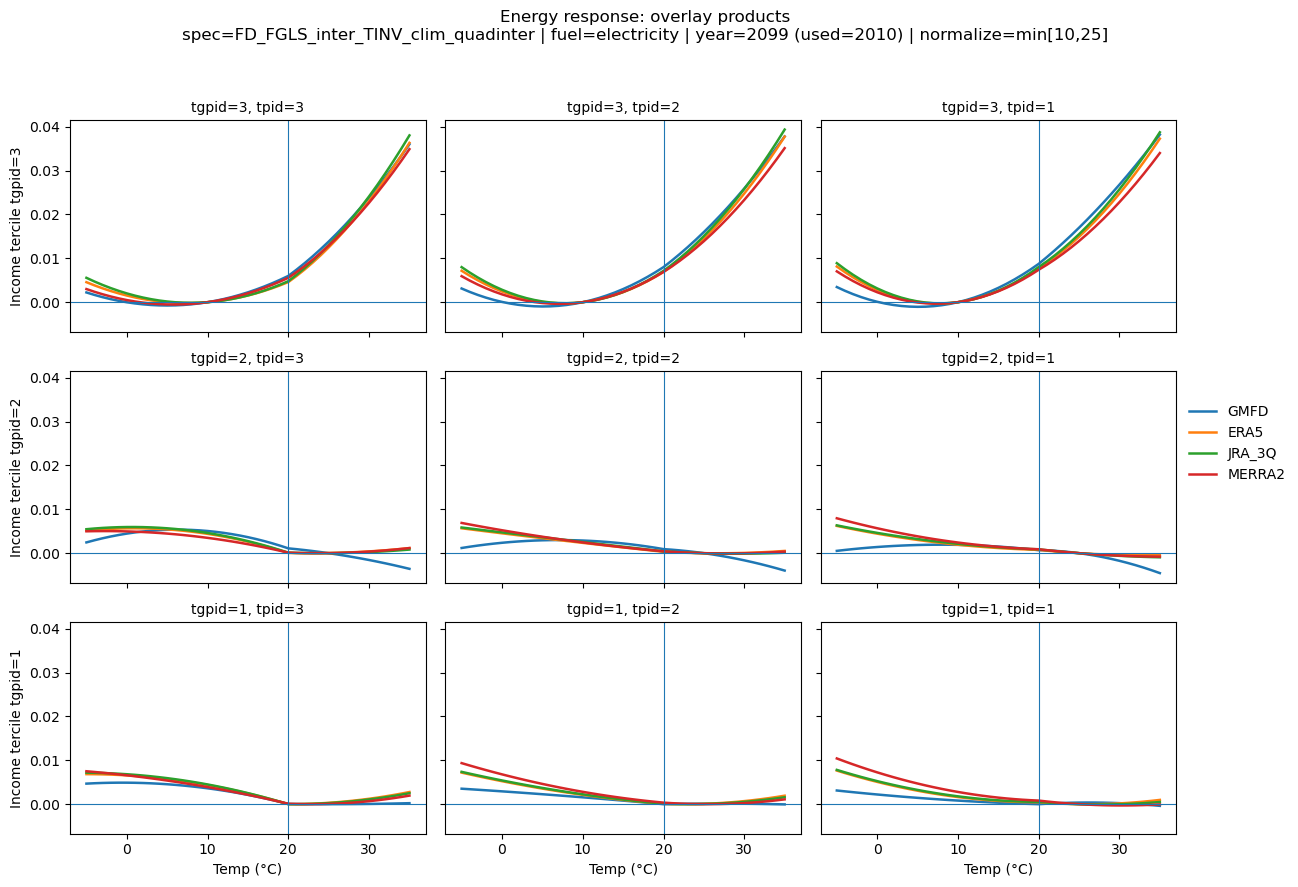

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================
EU = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")
STERD = EU / "data" / "regression" / "sters"

EDR = Path("/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression")
BREAK_DATA = EDR / "break_data_TINV_clim.dta"

# ============================================================
# SETTINGS
# ============================================================
PRODUCTS = ["GMFD", "ERA5", "JRA_3Q", "MERRA2"]
FUEL = "electricity"               # "electricity" or "other_energy"
IND_F = 1

MODEL_STEM = "FD_FGLS_inter_TINV_clim_quadinter"  
T = np.arange(-5, 36, 1.0)

ABOVE20 = (T >= 20).astype(float)
BELOW20 = (T < 20).astype(float)

# normalization like your figure label
NORMALIZE_MIN_10_25 = True
SLICE_MIN, SLICE_MAX = 10, 25

# IMPORTANT: to avoid out-of-sample blowups
YEAR_LABEL = 2099   # only for labeling
YEAR_USED  = 2010   # used inside the design matrix

OUTDIR = EU / "figures" / "python_compare"
OUTDIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================
def must_exist(p: Path, label="file"):
    if not p.exists():
        raise FileNotFoundError(f"Missing {label}: {p}")

def read_coeff_csv(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    return pd.Series(df["beta"].astype(float).values, index=df["parm"].astype(str).values)

def ibar_from_breakdata(bd: pd.DataFrame, fuel: str) -> float:
    maxcol = f"maxInc_largegpid_{fuel}"
    flagcol = f"largegpid_{fuel}"
    return float(bd.loc[bd[flagcol] == 1, maxcol].max())

def prep_break_maps_like_stata(bd: pd.DataFrame):
    """
    Mimic their Stata extraction exactly:
      duplicates drop tpid tgpid, force
      sort tpid tgpid
      tr_index = tr * 3 (1-indexed)
      subCDD = avgCDD_tpid[tr_index]
      subHDD = avgHDD_tpid[tr_index]
      subInc = avgInc_tgpid[lg]
    """
    b = bd.drop_duplicates(subset=["tpid", "tgpid"]).copy()
    b = b.sort_values(["tpid", "tgpid"]).reset_index(drop=True)

    # Income: in their file, avgInc_tgpid is constant within tgpid
    inc_by_lg = {}
    for lg in [1, 2, 3]:
        inc_by_lg[lg] = float(b.loc[b["tgpid"] == lg, "avgInc_tgpid"].iloc[0])

    # Climate: use their tr_index = tr*3 (Stata 1-indexed)
    cdd_by_tr, hdd_by_tr = {}, {}
    for tr in [1, 2, 3]:
        pos = tr * 3 - 1  # python 0-indexed
        cdd_by_tr[tr] = float(b.loc[pos, "avgCDD_tpid"])
        hdd_by_tr[tr] = float(b.loc[pos, "avgHDD_tpid"])

    return inc_by_lg, cdd_by_tr, hdd_by_tr

def normalize_curve(y: np.ndarray) -> np.ndarray:
    if not NORMALIZE_MIN_10_25:
        return y
    win = (T >= SLICE_MIN) & (T <= SLICE_MAX)
    return y - np.min(y[win])

def parm_candidates(pg: int, indf: int, term: str, product: str) -> list[str]:
    # allow both suffix and no suffix; plus possible "co." factor prefix variant
    return [
        f"c.indp{pg}#c.indf{indf}#c.{term}_{product}",
        f"c.indp{pg}#c.indf{indf}#c.{term}",
        f"co.indp{pg}#co.indf{indf}#co.{term}_{product}",
        f"co.indp{pg}#co.indf{indf}#co.{term}",
    ]

def resolve_name(coef_index: pd.Index, pg: int, indf: int, term: str, product: str) -> str | None:
    for nm in parm_candidates(pg, indf, term, product):
        if nm in coef_index:
            return nm
    return None

def build_design_quadinter(coef_index: pd.Index, *, fuel: str, product: str,
                           subInc: float, subCDD: float, subHDD: float,
                           ibar: float, year_used: int, indf: int):
    """
    Mirrors the Stata predictnl line for quadinter exactly (k=1,2).
    """
    pg = 1 if fuel == "electricity" else 2
    ig = 2 if subInc > ibar else 1
    deltacut = float(subInc - ibar)

    y = float(year_used)
    y2 = y * y

    names = []
    cols = []

    for k in [1, 2]:
        Tk = T ** k
        base = Tk - (20.0 ** k)
        below = (20.0 ** k) - Tk

        nm_temp   = resolve_name(coef_index, pg, indf, f"FD_temp{k}", product)
        nm_cdd    = resolve_name(coef_index, pg, indf, f"FD_cdd20_TINVtemp{k}", product)
        nm_hdd    = resolve_name(coef_index, pg, indf, f"FD_hdd20_TINVtemp{k}", product)
        nm_dc1    = resolve_name(coef_index, pg, indf, f"FD_dc1_lgdppc_MA15I{ig}temp{k}", product)

        nm_yt     = resolve_name(coef_index, pg, indf, f"FD_yeartemp{k}", product)
        nm_dc1y   = resolve_name(coef_index, pg, indf, f"FD_dc1_lgdppc_MA15yearI{ig}temp{k}", product)

        nm_y2t    = resolve_name(coef_index, pg, indf, f"FD_year2temp{k}", product)
        nm_dc1y2  = resolve_name(coef_index, pg, indf, f"FD_dc1_lgdppc_MA15year2I{ig}temp{k}", product)

        if nm_temp:
            names.append(nm_temp); cols.append(base)

        if nm_cdd:
            names.append(nm_cdd); cols.append(ABOVE20 * subCDD * base)

        if nm_hdd:
            names.append(nm_hdd); cols.append(BELOW20 * subHDD * below)

        if nm_dc1:
            names.append(nm_dc1); cols.append(deltacut * base)

        # lin/quad year terms
        if nm_yt:
            names.append(nm_yt); cols.append(y * base)

        if nm_dc1y:
            names.append(nm_dc1y); cols.append(deltacut * y * base)

        # quad year^2 terms
        if nm_y2t:
            names.append(nm_y2t); cols.append(y2 * base)

        if nm_dc1y2:
            names.append(nm_dc1y2); cols.append(deltacut * y2 * base)

    if not cols:
        raise RuntimeError(f"No plotting terms resolved for {product}. Check coefficient naming.")
    X = np.column_stack(cols)
    return X, names

# ============================================================
# LOAD break_data + prep Stata-like maps
# ============================================================
must_exist(BREAK_DATA, "break_data")
bd = pd.read_stata(BREAK_DATA)
ibar = ibar_from_breakdata(bd, FUEL)
inc_by_lg, cdd_by_tr, hdd_by_tr = prep_break_maps_like_stata(bd)

# ============================================================
# PRELOAD COEFFICIENTS
# ============================================================
coefs = {}
for prod in PRODUCTS:
    coef_path = STERD / f"{MODEL_STEM}_{prod}_coeff.csv"
    must_exist(coef_path, f"{prod} coeff")
    coefs[prod] = read_coeff_csv(coef_path)

# ============================================================
# PLOT 3x3 OVERLAY (LINES ONLY)
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True, sharey=True)
fig.suptitle(
    f"Energy response: overlay products\n"
    f"spec={MODEL_STEM} | fuel={FUEL} | year={YEAR_LABEL} (used={YEAR_USED}) | normalize=min[{SLICE_MIN},{SLICE_MAX}]",
    y=0.98
)

# Stata loops: lg=3..1, tr=3..1
for r, lg in enumerate([3, 2, 1]):
    for c, tr in enumerate([3, 2, 1]):
        ax = axes[r, c]
        subInc = inc_by_lg[lg]
        subCDD = cdd_by_tr[tr]
        subHDD = hdd_by_tr[tr]

        for prod in PRODUCTS:
            coef = coefs[prod]
            X, names = build_design_quadinter(
                coef.index,
                fuel=FUEL, product=prod,
                subInc=subInc, subCDD=subCDD, subHDD=subHDD,
                ibar=ibar, year_used=YEAR_USED, indf=IND_F
            )
            beta = coef.loc[names].values
            y = normalize_curve(X @ beta)
            ax.plot(T, y, linewidth=1.8, label=prod)

        ax.axhline(0, linewidth=0.8)
        ax.axvline(20, linewidth=0.8)
        ax.set_title(f"tgpid={lg}, tpid={tr}", fontsize=10)
        if c == 0:
            ax.set_ylabel(f"Income tercile tgpid={lg}", fontsize=10)
        if r == 2:
            ax.set_xlabel("Temp (°C)", fontsize=10)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", frameon=False)
plt.tight_layout(rect=[0, 0, 0.92, 0.95])

out = OUTDIR / f"overlay_lines_3x3_{MODEL_STEM}_{FUEL}_year{YEAR_LABEL}_used{YEAR_USED}.pdf"
fig.savefig(out)
print("Saved:", out)

plt.show()


In [30]:
print("CDD by tpid:", cdd_by_tr)
print("HDD by tpid:", hdd_by_tr)


CDD by tpid: {1: 2412.935302734375, 2: 1115.5257568359375, 3: 223.8359832763672}
HDD by tpid: {1: 156.36099243164062, 2: 1178.0726318359375, 3: 3925.803955078125}


In [31]:
print("Income by tgpid:", inc_by_lg)


Income by tgpid: {1: 7.4978461265563965, 2: 8.77016830444336, 3: 9.997271537780762}


In [32]:
bd.groupby("tgpid")["avgInc_tgpid"].mean().sort_index()


tgpid
1.0    7.497846
2.0    8.770168
3.0    9.997272
Name: avgInc_tgpid, dtype: float32

Saved: /user/ab5405/summeraliaclimate/code/energy_uncertainty/figures/python_compare/overlay_lines_3x3_FD_FGLS_inter_TINV_clim_quadinter_electricity_year2099_used2010_HOT2COLD.pdf


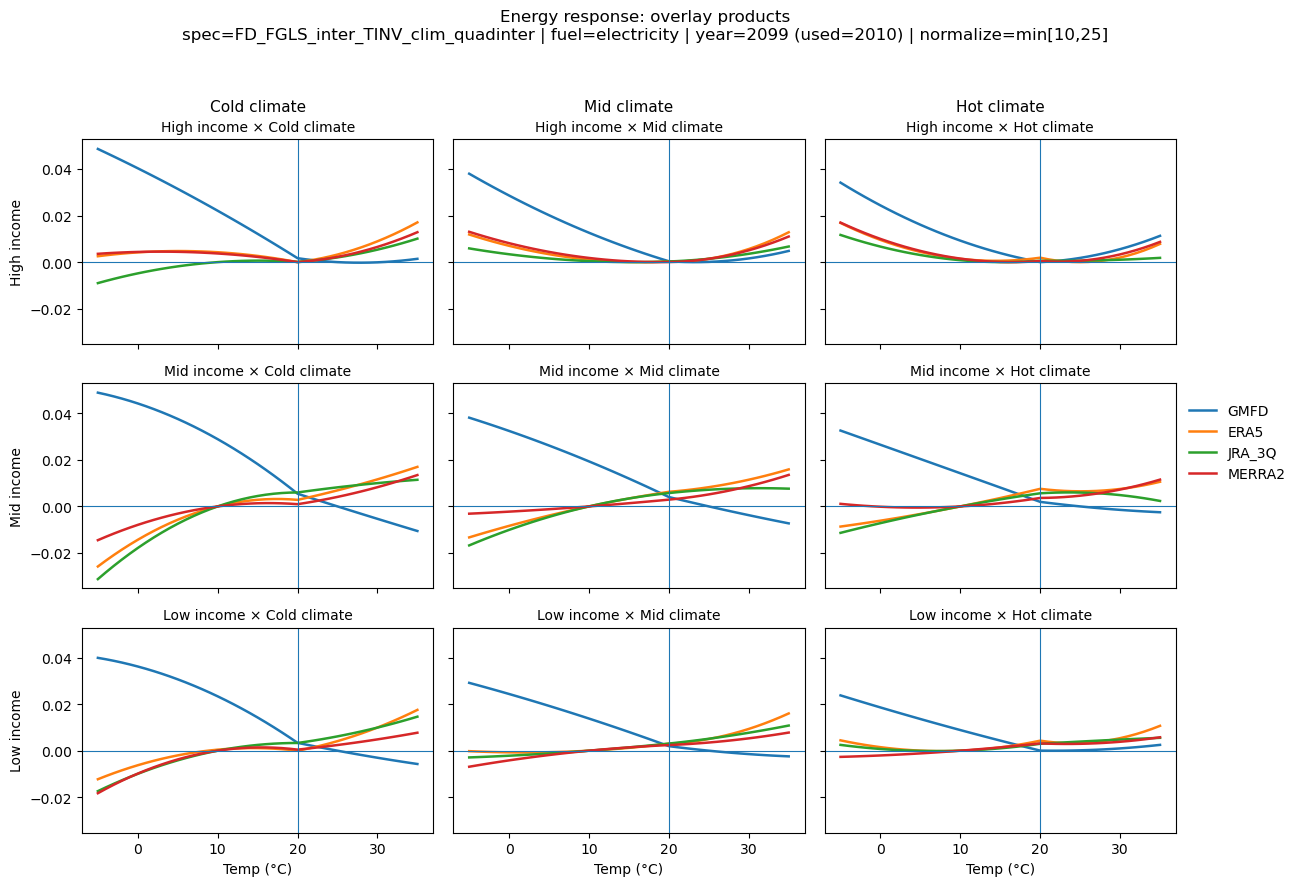

In [34]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================
EU = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")
STERD = EU / "data" / "regression" / "sters"

EDR = Path("/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression")
BREAK_DATA = EDR / "break_data_TINV_clim.dta"

# ============================================================
# SETTINGS
# ============================================================
PRODUCTS = ["GMFD", "ERA5", "JRA_3Q", "MERRA2"]
FUEL = "electricity"               # "electricity" or "other_energy"
IND_F = 1

MODEL_STEM = "FD_FGLS_inter_TINV_clim_quadinter"
T = np.arange(-5, 36, 1.0)

ABOVE20 = (T >= 20).astype(float)
BELOW20 = (T < 20).astype(float)

# normalization like your figure label
NORMALIZE_MIN_10_25 = True
SLICE_MIN, SLICE_MAX = 10, 25

# IMPORTANT: to avoid out-of-sample blowups
YEAR_LABEL = 2099   # only for labeling
YEAR_USED  = 2010   # used inside the design matrix

OUTDIR = EU / "figures" / "python_compare"
OUTDIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================
def must_exist(p: Path, label="file"):
    if not p.exists():
        raise FileNotFoundError(f"Missing {label}: {p}")

def read_coeff_csv(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    return pd.Series(df["beta"].astype(float).values, index=df["parm"].astype(str).values)

def ibar_from_breakdata(bd: pd.DataFrame, fuel: str) -> float:
    maxcol = f"maxInc_largegpid_{fuel}"
    flagcol = f"largegpid_{fuel}"
    return float(bd.loc[bd[flagcol] == 1, maxcol].max())

def prep_income_map(bd: pd.DataFrame):
    """
    Robust income mapping: mean avgInc_tgpid by tgpid.
    (Your printout confirmed tgpid 1<2<3.)
    """
    inc_by_lg = bd.groupby("tgpid")["avgInc_tgpid"].mean().to_dict()
    # make sure keys are ints 1,2,3
    return {int(k): float(v) for k, v in inc_by_lg.items()}

def prep_climate_maps(bd: pd.DataFrame):
    """
    Robust climate mapping: mean avgCDD_tpid / avgHDD_tpid by tpid.
    Your printout confirmed:
      tpid=1 hottest (high CDD, low HDD)
      tpid=3 coldest (low CDD, high HDD)
    """
    cdd_by_tr = bd.groupby("tpid")["avgCDD_tpid"].mean().to_dict()
    hdd_by_tr = bd.groupby("tpid")["avgHDD_tpid"].mean().to_dict()
    return ({int(k): float(v) for k, v in cdd_by_tr.items()},
            {int(k): float(v) for k, v in hdd_by_tr.items()})

def normalize_curve(y: np.ndarray) -> np.ndarray:
    if not NORMALIZE_MIN_10_25:
        return y
    win = (T >= SLICE_MIN) & (T <= SLICE_MAX)
    return y - np.min(y[win])

def parm_candidates(pg: int, indf: int, term: str, product: str) -> list[str]:
    return [
        f"c.indp{pg}#c.indf{indf}#c.{term}_{product}",
        f"c.indp{pg}#c.indf{indf}#c.{term}",
        f"co.indp{pg}#co.indf{indf}#co.{term}_{product}",
        f"co.indp{pg}#co.indf{indf}#co.{term}",
    ]

def resolve_name(coef_index: pd.Index, pg: int, indf: int, term: str, product: str):
    for nm in parm_candidates(pg, indf, term, product):
        if nm in coef_index:
            return nm
    return None

def build_design_quadinter(coef_index: pd.Index, *, fuel: str, product: str,
                           subInc: float, subCDD: float, subHDD: float,
                           ibar: float, year_used: int, indf: int):
    pg = 1 if fuel == "electricity" else 2
    ig = 2 if subInc > ibar else 1
    deltacut = float(subInc - ibar)

    y = float(year_used)
    y2 = y * y

    names, cols = [], []

    for k in [1, 2]:
        Tk = T ** k
        base = Tk - (20.0 ** k)
        below = (20.0 ** k) - Tk

        nm_temp   = resolve_name(coef_index, pg, indf, f"FD_temp{k}", product)
        nm_cdd    = resolve_name(coef_index, pg, indf, f"FD_cdd20_TINVtemp{k}", product)
        nm_hdd    = resolve_name(coef_index, pg, indf, f"FD_hdd20_TINVtemp{k}", product)
        nm_dc1    = resolve_name(coef_index, pg, indf, f"FD_dc1_lgdppc_MA15I{ig}temp{k}", product)

        nm_yt     = resolve_name(coef_index, pg, indf, f"FD_yeartemp{k}", product)
        nm_dc1y   = resolve_name(coef_index, pg, indf, f"FD_dc1_lgdppc_MA15yearI{ig}temp{k}", product)
        nm_y2t    = resolve_name(coef_index, pg, indf, f"FD_year2temp{k}", product)
        nm_dc1y2  = resolve_name(coef_index, pg, indf, f"FD_dc1_lgdppc_MA15year2I{ig}temp{k}", product)

        if nm_temp:
            names.append(nm_temp); cols.append(base)

        if nm_cdd:
            names.append(nm_cdd); cols.append(ABOVE20 * subCDD * base)

        if nm_hdd:
            names.append(nm_hdd); cols.append(BELOW20 * subHDD * below)

        if nm_dc1:
            names.append(nm_dc1); cols.append(deltacut * base)

        if nm_yt:
            names.append(nm_yt); cols.append(y * base)

        if nm_dc1y:
            names.append(nm_dc1y); cols.append(deltacut * y * base)

        if nm_y2t:
            names.append(nm_y2t); cols.append(y2 * base)

        if nm_dc1y2:
            names.append(nm_dc1y2); cols.append(deltacut * y2 * base)

    if not cols:
        raise RuntimeError(f"No plotting terms resolved for {product}. Check coefficient naming.")
    return np.column_stack(cols), names

# ============================================================
# LOAD break_data + maps
# ============================================================
must_exist(BREAK_DATA, "break_data")
bd = pd.read_stata(BREAK_DATA)

ibar = ibar_from_breakdata(bd, FUEL)
inc_by_lg = prep_income_map(bd)
cdd_by_tr, hdd_by_tr = prep_climate_maps(bd)

# Labels (based on verified ordering)
inc_label  = {1: "Low income", 2: "Mid income", 3: "High income"}
clim_label = {1: "Hot climate", 2: "Mid climate", 3: "Cold climate"}

# ============================================================
# PRELOAD COEFFICIENTS
# ============================================================
coefs = {}
for prod in PRODUCTS:
    coef_path = STERD / f"{MODEL_STEM}_{prod}_coeff.csv"
    must_exist(coef_path, f"{prod} coeff")
    coefs[prod] = read_coeff_csv(coef_path)

# ============================================================
# PLOT 3x3 OVERLAY (LINES ONLY)
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True, sharey=True)
fig.suptitle(
    f"Energy response: overlay products\n"
    f"spec={MODEL_STEM} | fuel={FUEL} | year={YEAR_LABEL} (used={YEAR_USED}) | normalize=min[{SLICE_MIN},{SLICE_MAX}]",
    y=0.98
)

# Rows: high -> mid -> low income
row_order = [3, 2, 1]

# Columns: hot -> mid -> cold climate  (FIXED)
col_order = [3, 2, 1]

for r, lg in enumerate(row_order):
    for c, tr in enumerate(col_order):
        ax = axes[r, c]
        subInc = inc_by_lg[lg]
        subCDD = cdd_by_tr[tr]
        subHDD = hdd_by_tr[tr]

        for prod in PRODUCTS:
            coef = coefs[prod]
            X, names = build_design_quadinter(
                coef.index,
                fuel=FUEL, product=prod,
                subInc=subInc, subCDD=subCDD, subHDD=subHDD,
                ibar=ibar, year_used=YEAR_USED, indf=IND_F
            )
            beta = coef.loc[names].values
            y = normalize_curve(X @ beta)
            ax.plot(T, y, linewidth=1.8, label=prod)

        ax.axhline(0, linewidth=0.8)
        ax.axvline(20, linewidth=0.8)

        # readable titles
        ax.set_title(f"{inc_label[lg]} × {clim_label[tr]}", fontsize=10)

        # axis labels
        if c == 0:
            ax.set_ylabel(inc_label[lg], fontsize=10)
        if r == 2:
            ax.set_xlabel("Temp (°C)", fontsize=10)

# column headers (optional: clearer than repeating in titles)
for c, tr in enumerate(col_order):
    axes[0, c].annotate(
        clim_label[tr],
        xy=(0.5, 1.12), xycoords="axes fraction",
        ha="center", va="bottom", fontsize=11
    )

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", frameon=False)
plt.tight_layout(rect=[0, 0, 0.92, 0.95])

out = OUTDIR / f"overlay_lines_3x3_{MODEL_STEM}_{FUEL}_year{YEAR_LABEL}_used{YEAR_USED}_HOT2COLD.pdf"
fig.savefig(out)
print("Saved:", out)

plt.show()


In [37]:
def resolve_used_name(coef: pd.Series, pg: int, indf: int, term: str, product: str):
    for nm in candidates(pg, indf, term, product):
        if nm in coef.index:
            return nm
    return None

def debug_terms(coef: pd.Series, label: str, product: str, fuel: str, indf: int):
    pg = 1 if fuel == "electricity" else 2
    terms = [
        "FD_temp1","FD_temp2",
        "FD_cdd20_TINVtemp1","FD_cdd20_TINVtemp2",
        "FD_hdd20_TINVtemp1","FD_hdd20_TINVtemp2",
        "FD_yeartemp1","FD_yeartemp2",
        "FD_year2temp1","FD_year2temp2",
        # dc1 depends on ig; do after you compute ig
    ]
    print(f"\n--- {label} names actually used ---")
    for t in terms:
        nm = resolve_used_name(coef, pg, indf, t, product)
        val = float(coef[nm]) if nm is not None else None
        print(f"{t:28s} -> {nm} | {val}")


Saved: /user/ab5405/summeraliaclimate/code/energy_uncertainty/figures/python_compare/overlay_lines_3x3_FD_FGLS_inter_TINV_clim_quadinter_electricity_full_year2010.pdf


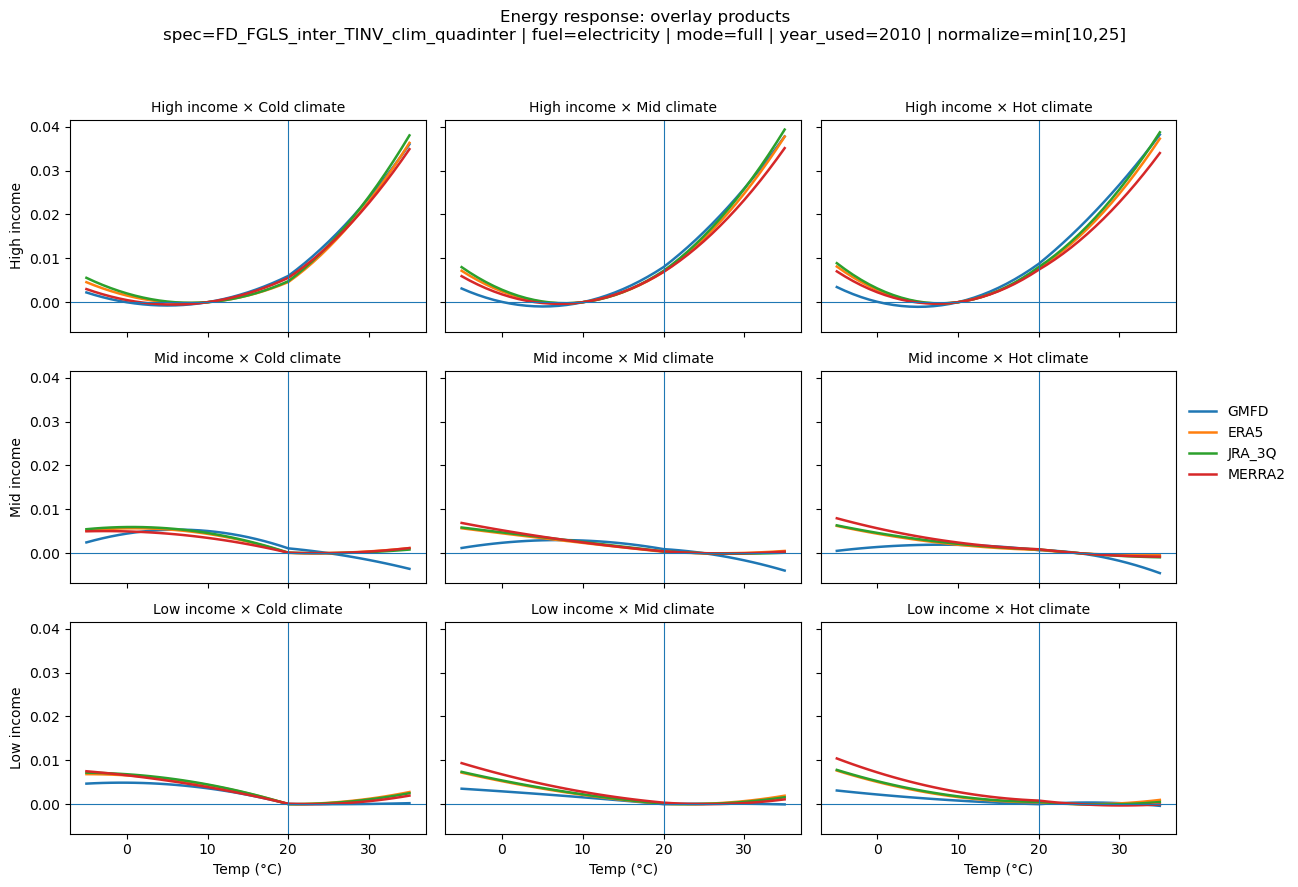

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================
EU = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")
STERD = EU / "data" / "regression" / "sters"

EDR = Path("/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression")
BREAK_DATA = EDR / "break_data_TINV_clim.dta"

# ============================================================
# SETTINGS
# ============================================================
PRODUCTS = ["GMFD", "ERA5", "JRA_3Q", "MERRA2"]
FUEL = "electricity"               # "electricity" or "other_energy"
IND_F = 1

MODEL_STEM = "FD_FGLS_inter_TINV_clim_quadinter"

T = np.arange(-5, 36, 1.0)
ABOVE20 = (T >= 20).astype(float)
BELOW20 = (T < 20).astype(float)

NORMALIZE_MIN_10_25 = True
SLICE_MIN, SLICE_MAX = 10, 25

# Choose what you want:
#   "full"     = matches Stata quadinter figure logic (uses year and year^2)
#   "baseline" = excludes year and year^2 blocks (often what you want for “form” comparisons)
PLOT_MODE = "full"

YEAR_USED = 2010  # use this if PLOT_MODE == "full"
# YEAR_USED = 2010  # you can swap if you want

OUTDIR = EU / "figures" / "python_compare"
OUTDIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================
def must_exist(p: Path, label="file"):
    if not p.exists():
        raise FileNotFoundError(f"Missing {label}: {p}")

def read_coeff_csv(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    if not {"parm", "beta"}.issubset(df.columns):
        raise ValueError(f"Expected parm,beta in {path}, got {df.columns.tolist()}")
    parm = df["parm"].astype(str).str.strip()   # <<< IMPORTANT
    beta = df["beta"].astype(float)
    return pd.Series(beta.values, index=parm.values)

def ibar_from_breakdata(bd: pd.DataFrame, fuel: str) -> float:
    maxcol = f"maxInc_largegpid_{fuel}"
    flagcol = f"largegpid_{fuel}"
    return float(bd.loc[bd[flagcol] == 1, maxcol].max())

def prep_income_map(bd: pd.DataFrame):
    inc_by_lg = bd.groupby("tgpid")["avgInc_tgpid"].mean().to_dict()
    return {int(k): float(v) for k, v in inc_by_lg.items()}

def prep_climate_maps(bd: pd.DataFrame):
    cdd_by_tr = bd.groupby("tpid")["avgCDD_tpid"].mean().to_dict()
    hdd_by_tr = bd.groupby("tpid")["avgHDD_tpid"].mean().to_dict()
    return ({int(k): float(v) for k, v in cdd_by_tr.items()},
            {int(k): float(v) for k, v in hdd_by_tr.items()})

def normalize_curve(y: np.ndarray) -> np.ndarray:
    if not NORMALIZE_MIN_10_25:
        return y
    win = (T >= SLICE_MIN) & (T <= SLICE_MAX)
    return y - np.min(y[win])

def parm_candidates(pg: int, indf: int, term: str, product: str) -> list[str]:
    # Try with suffix and without; also "co." vs "c."
    return [
        f"c.indp{pg}#c.indf{indf}#c.{term}_{product}",
        f"c.indp{pg}#c.indf{indf}#c.{term}",
        f"co.indp{pg}#co.indf{indf}#co.{term}_{product}",
        f"co.indp{pg}#co.indf{indf}#co.{term}",
    ]

def resolve_name(coef_index: pd.Index, pg: int, indf: int, term: str, product: str):
    # exact match first
    for nm in parm_candidates(pg, indf, term, product):
        if nm in coef_index:
            return nm
    return None

def build_design_quadinter(
    coef_index: pd.Index,
    *,
    fuel: str,
    product: str,
    subInc: float,
    subCDD: float,
    subHDD: float,
    ibar: float,
    year_used: int,
    indf: int,
    plot_mode: str,
):
    """
    plot_mode:
      - "full": match Stata quadinter figure logic (includes year and year^2 blocks)
      - "baseline": exclude year/year^2 blocks entirely (form comparisons)
    """
    pg = 1 if fuel == "electricity" else 2
    ig = 2 if subInc > ibar else 1
    deltacut = float(subInc - ibar)

    y = float(year_used)
    y2 = y * y

    names, cols = [], []

    for k in [1, 2]:
        Tk = T ** k
        base = Tk - (20.0 ** k)
        below = (20.0 ** k) - Tk

        # core terms
        nm_temp = resolve_name(coef_index, pg, indf, f"FD_temp{k}", product)
        nm_cdd  = resolve_name(coef_index, pg, indf, f"FD_cdd20_TINVtemp{k}", product)
        nm_hdd  = resolve_name(coef_index, pg, indf, f"FD_hdd20_TINVtemp{k}", product)
        nm_dc1  = resolve_name(coef_index, pg, indf, f"FD_dc1_lgdppc_MA15I{ig}temp{k}", product)

        if nm_temp:
            names.append(nm_temp); cols.append(base)
        if nm_cdd:
            names.append(nm_cdd); cols.append(ABOVE20 * subCDD * base)
        if nm_hdd:
            names.append(nm_hdd); cols.append(BELOW20 * subHDD * below)
        if nm_dc1:
            names.append(nm_dc1); cols.append(deltacut * base)

        if plot_mode == "full":
            # year and year^2 blocks (quadinter)
            nm_yt    = resolve_name(coef_index, pg, indf, f"FD_yeartemp{k}", product)
            nm_dc1y  = resolve_name(coef_index, pg, indf, f"FD_dc1_lgdppc_MA15yearI{ig}temp{k}", product)
            nm_y2t   = resolve_name(coef_index, pg, indf, f"FD_year2temp{k}", product)
            nm_dc1y2 = resolve_name(coef_index, pg, indf, f"FD_dc1_lgdppc_MA15year2I{ig}temp{k}", product)

            if nm_yt:
                names.append(nm_yt); cols.append(y * base)
            if nm_dc1y:
                names.append(nm_dc1y); cols.append(deltacut * y * base)
            if nm_y2t:
                names.append(nm_y2t); cols.append(y2 * base)
            if nm_dc1y2:
                names.append(nm_dc1y2); cols.append(deltacut * y2 * base)

    if not cols:
        raise RuntimeError(f"No plotting terms resolved for {product}. Check coefficient naming.")
    return np.column_stack(cols), names

# ============================================================
# LOAD break_data + maps
# ============================================================
must_exist(BREAK_DATA, "break_data")
bd = pd.read_stata(BREAK_DATA)

ibar = ibar_from_breakdata(bd, FUEL)
inc_by_lg = prep_income_map(bd)
cdd_by_tr, hdd_by_tr = prep_climate_maps(bd)

inc_label  = {1: "Low income", 2: "Mid income", 3: "High income"}
clim_label = {1: "Hot climate", 2: "Mid climate", 3: "Cold climate"}  # tpid ordering

# ============================================================
# PRELOAD COEFFICIENTS
# ============================================================
coefs = {}
for prod in PRODUCTS:
    coef_path = STERD / f"{MODEL_STEM}_{prod}_coeff.csv"
    must_exist(coef_path, f"{prod} coeff")
    coefs[prod] = read_coeff_csv(coef_path)

# ============================================================
# PLOT 3x3 OVERLAY
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True, sharey=True)
fig.suptitle(
    f"Energy response: overlay products\n"
    f"spec={MODEL_STEM} | fuel={FUEL} | mode={PLOT_MODE} | year_used={YEAR_USED} | normalize=min[{SLICE_MIN},{SLICE_MAX}]",
    y=0.98
)

row_order = [3, 2, 1]   # high -> mid -> low income (matches paper-style layout)
col_order = [3, 2, 1]   # hot -> mid -> cold climate  <<< FIXED

for r, lg in enumerate(row_order):
    for c, tr in enumerate(col_order):
        ax = axes[r, c]
        subInc = inc_by_lg[lg]
        subCDD = cdd_by_tr[tr]
        subHDD = hdd_by_tr[tr]

        for prod in PRODUCTS:
            coef = coefs[prod]
            X, names = build_design_quadinter(
                coef.index,
                fuel=FUEL, product=prod,
                subInc=subInc, subCDD=subCDD, subHDD=subHDD,
                ibar=ibar, year_used=YEAR_USED, indf=IND_F,
                plot_mode=PLOT_MODE,
            )
            beta = coef.loc[names].values
            y = normalize_curve(X @ beta)
            ax.plot(T, y, linewidth=1.8, label=prod)

        ax.axhline(0, linewidth=0.8)
        ax.axvline(20, linewidth=0.8)

        ax.set_title(f"{inc_label[lg]} × {clim_label[tr]}", fontsize=10)

        if c == 0:
            ax.set_ylabel(inc_label[lg], fontsize=10)
        if r == 2:
            ax.set_xlabel("Temp (°C)", fontsize=10)

# legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", frameon=False)
plt.tight_layout(rect=[0, 0, 0.92, 0.95])

out = OUTDIR / f"overlay_lines_3x3_{MODEL_STEM}_{FUEL}_{PLOT_MODE}_year{YEAR_USED}.pdf"
fig.savefig(out)
print("Saved:", out)

plt.show()


In [4]:
df = pd.read_stata(ORIG_PANEL, columns=["year","FD_temp1_GMFD","FD_yeartemp1_GMFD","FD_year2temp1_GMFD"])
df = df.dropna()
print((df["FD_yeartemp1_GMFD"] / df["FD_temp1_GMFD"]).describe())


count     7720.000000
mean      2007.842839
std       1314.549073
min     -28595.464718
25%       1931.034414
50%       2000.689481
75%       2058.045918
max      36849.633510
dtype: float64


In [5]:
def debug_one_cell(lg=3, tr=1):
    subInc = inc_by_lg[lg]
    subCDD = cdd_by_tr[tr]
    subHDD = hdd_by_tr[tr]

    for prod in PRODUCTS:
        coef = coefs[prod]
        X, names = build_design_quadinter(
            coef.index,
            fuel=FUEL, product=prod,
            subInc=subInc, subCDD=subCDD, subHDD=subHDD,
            ibar=ibar, year_used=YEAR_USED, indf=IND_F,
            plot_mode=PLOT_MODE,
        )
        beta = coef.loc[names].values
        contrib = (X * beta).sum(axis=1)
        # show peak absolute contribution by block-ish name
        print("\n", prod, "n_terms=", len(names))
        print(" max|y|=", np.max(np.abs(contrib)))
        # show the biggest 10 coefficients being used
        top = pd.DataFrame({"name": names, "beta": beta, "absbeta": np.abs(beta)}).sort_values("absbeta", ascending=False).head(10)
        print(top[["name","beta"]].to_string(index=False))

debug_one_cell()



 GMFD n_terms= 16
 max|y|= 0.029466590978633578
                                            name          beta
     c.indp1#c.indf1#c.FD_dc1_lgdppc_MA15I2temp1  2.966903e-02
                      c.indp1#c.indf1#c.FD_temp1 -1.805505e-02
     c.indp1#c.indf1#c.FD_dc1_lgdppc_MA15I2temp2 -2.045644e-03
                      c.indp1#c.indf1#c.FD_temp2  8.455941e-04
            c.indp1#c.indf1#c.FD_cdd20_TINVtemp1  2.849968e-07
            c.indp1#c.indf1#c.FD_hdd20_TINVtemp1 -4.076005e-08
c.indp1#c.indf1#c.FD_dc1_lgdppc_MA15year2I2temp1 -7.523099e-09
            c.indp1#c.indf1#c.FD_cdd20_TINVtemp2 -5.489434e-09
                 c.indp1#c.indf1#c.FD_year2temp1  4.519057e-09
            c.indp1#c.indf1#c.FD_hdd20_TINVtemp2  3.788786e-09

 ERA5 n_terms= 16
 max|y|= 0.029519493577178868
                                            name          beta
     c.indp1#c.indf1#c.FD_dc1_lgdppc_MA15I2temp1  1.499080e-02
                      c.indp1#c.indf1#c.FD_temp1  3.443850e-03
     c.indp1#c.indf1

In [6]:
def summarize_fd_temp(regsort_path):
    df = pd.read_stata(regsort_path, columns=["FD_temp1","FD_temp2","FD_load_pc"])
    return df[["FD_temp1","FD_temp2","FD_load_pc"]].describe().loc[["mean","std","min","max"]]

for prod in ["GMFD","ERA5","JRA_3Q","MERRA2"]:
    p = EU/"data"/"regression"/f"{prod}_TINV_clim_regsort.dta"
    print("\n", prod, p)
    print(summarize_fd_temp(p))



 GMFD /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/GMFD_TINV_clim_regsort.dta
         FD_temp1      FD_temp2  FD_load_pc
mean     5.161643    229.816899    0.029937
std    204.426117   6992.556562    3.774959
min  -1038.046072 -45649.198654 -148.311310
max    948.205108  52758.035372   69.180954

 ERA5 /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/ERA5_TINV_clim_regsort.dta
         FD_temp1      FD_temp2  FD_load_pc
mean    10.491542    550.163289    0.029937
std    201.098964   6805.950477    3.774959
min  -1010.700490 -32481.245105 -148.311310
max    902.621895  32007.300852   69.180954

 JRA_3Q /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/JRA_3Q_TINV_clim_regsort.dta
         FD_temp1      FD_temp2  FD_load_pc
mean     8.697729    473.717922    0.029937
std    199.413349   6767.039816    3.774959
min  -1007.005203 -32622.221986 -148.311310
max    919.901246  32710.976559   69.180954

 MERRA2 /user/ab5405

In [7]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================
EU = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty")

NEW_STERD = EU / "data" / "regression" / "sters"
OLD_STERD = EU / "output_original" / "sters"

EDR = Path("/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression")
BREAK_DATA = EDR / "break_data_TINV_clim.dta"

# ============================================================
# SETTINGS
# ============================================================
FUEL = "electricity"          # "electricity" or "other_energy"
IND_F = 1
MODEL_STEM = "FD_FGLS_inter_TINV_clim_quadinter"

# Choose what you want to compare:
YEAR_USED = 2010              # 2010 for baseline sanity; 2099 if you insist
MODE = "baseline"             # "baseline" or "full" (full includes year/year2 terms)

# Coefficient files
OLD_COEF = OLD_STERD / f"{MODEL_STEM}_coeff.csv"            # old export from .ster
NEW_COEF = NEW_STERD / f"{MODEL_STEM}_GMFD_coeff.csv"       # your GMFD output

# Temperature grid (matches Stata)
T = np.arange(-5, 36, 1.0)
ABOVE20 = (T >= 20).astype(float)
BELOW20 = (T < 20).astype(float)

# Normalization
NORMALIZE_MIN_10_25 = True
SLICE_MIN, SLICE_MAX = 10, 25

# ============================================================
# HELPERS
# ============================================================
def must_exist(p: Path, label="file"):
    if not p.exists():
        raise FileNotFoundError(f"Missing {label}: {p}")

def read_coeff_csv(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    if not {"parm","beta"}.issubset(df.columns):
        raise ValueError(f"Expected columns parm,beta in {path}")
    return pd.Series(df["beta"].astype(float).values, index=df["parm"].astype(str).values)

def ibar_from_breakdata(bd: pd.DataFrame, fuel: str) -> float:
    maxcol = f"maxInc_largegpid_{fuel}"
    flagcol = f"largegpid_{fuel}"
    return float(bd.loc[bd[flagcol] == 1, maxcol].max())

def normalize_curve(y: np.ndarray) -> np.ndarray:
    if not NORMALIZE_MIN_10_25:
        return y
    win = (T >= SLICE_MIN) & (T <= SLICE_MAX)
    return y - np.min(y[win])

def prep_breakdata_like_stata(bd: pd.DataFrame):
    """
    EXACTLY mimic their Stata extraction:

      duplicates drop tpid tgpid, force
      sort tpid tgpid
      tr_index = tr*3 (1-indexed)
      subCDD = avgCDD_tpid[tr_index]
      subHDD = avgHDD_tpid[tr_index]
      subInc = avgInc_tgpid[lg]
    """
    b = bd.drop_duplicates(subset=["tpid", "tgpid"]).copy()
    b = b.sort_values(["tpid", "tgpid"]).reset_index(drop=True)

    # income terciles: pick first row per tgpid
    inc_by_lg = {}
    for lg in [1,2,3]:
        inc_by_lg[lg] = float(b.loc[b["tgpid"] == lg, "avgInc_tgpid"].iloc[0])

    # climate terciles: tr_index = tr*3 (Stata 1-indexed) => pos = tr*3 -_


In [8]:
import pandas as pd
from pathlib import Path

BREAK_DATA = Path("/user/ab5405/summeraliaclimate/code/energy_consumption/energy_data_release_2021oct21/DATA/regression/break_data_TINV_clim.dta")

bd = pd.read_stata(BREAK_DATA)

ibar = bd.loc[bd["largegpid_electricity"]==1, "maxInc_largegpid_electricity"].max()
print("ibar:", ibar)

b = bd.drop_duplicates(subset=["tpid","tgpid"]).sort_values(["tpid","tgpid"]).reset_index(drop=True)
subInc = {1: float(b.loc[0,"avgInc_tgpid"]), 2: float(b.loc[1,"avgInc_tgpid"]), 3: float(b.loc[2,"avgInc_tgpid"])}
print("subInc:", subInc)

for lg in [1,2,3]:
    print("deltacut(lg=%d) ="%lg, subInc[lg]-ibar)


ibar: 9.08701
subInc: {1: 7.4978461265563965, 2: 8.77016830444336, 3: 9.997271537780762}
deltacut(lg=1) = -1.5891643
deltacut(lg=2) = -0.31684208
deltacut(lg=3) = 0.91026115
